# Part A: Conditional DCGAN on CIFAR10

This notebook builds and evaluates a class-conditional DCGAN on CIFAR10, producing a balanced set of 100 generated images for each of the 10 classes. It provides an adversarial generative baseline that can be compared with the conditional VAE using the same dataset, class conditioning, qualitative review, and image-quality evaluation.

## 1. Imports and Setup

In [1]:
# Import tensorflow/keras, numpy, matplotlib; set random seed for reproducibility.
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from torchvision.transforms import transforms
import torch.nn.functional as F
from torchvision.transforms import functional as F_t
from torchvision.datasets import CIFAR10
import datasets 
import matplotlib.pyplot as plt
import os
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
cpu_cores = min(16, os.cpu_count()-2 or 1)
print(f'running on {device}')

c:\Users\Admin\Desktop\st1504-ca2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


running on cuda


In [2]:
import seaborn as sns

# Shared design system for all notebooks in dele/: a 10-color categorical palette
# (one hue per CIFAR10 class), validated for lightness, chroma, and colorblind
# separation with the dataviz skill's validator (all checks pass).
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

## 2. Approach

A DCGAN complements the CVAE by learning through an adversarial discriminator, which can encourage sharper samples without an explicit pixel-wise reconstruction objective. Both networks receive the requested class: the label gives the generator information that it can use to specialize its output, while the discriminator evaluates the image together with that same condition. This creates a class-conditional baseline, although the later NMI evaluation is still required to determine whether the trained generator actually uses the supplied label effectively.

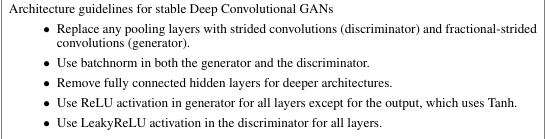

## 3. Preprocessing

### 3.1 Normalize Pixel Values

Each original CIFAR10 pixel is transformed with `x / 127.5 - 1`, mapping the uint8 range `[0, 255]` to `[-1, 1]`. This matches the generator's final `tanh` activation, ensuring that real and generated images enter the discriminator on the same numerical scale.

In [3]:
image_data = datasets.load_dataset('uoft-cs/cifar10').with_format('torch')

In [4]:
# Cast images to float32 and normalize pixel values to [-1, 1] to match the generator's tanh output range.
train_data = image_data['train'].map(lambda x: {'img': x/127.5 - 1}, input_columns=['img'], batched=True, batch_size=500, num_proc=cpu_cores)
test_data = image_data['test'].map(lambda x: {'img': x/127.5 - 1}, input_columns=['img'], batched=True, batch_size=500, num_proc=cpu_cores)


In [5]:
# one batch
sample_batch = torch.tensor(test_data.select(range(64)).with_format(None)['img'])
print(f'range: {sample_batch.min()} to {sample_batch.max()}')

range: -1.0 to 1.0


### 3.2 Encode Labels

The class label is one hot encoded. The generator then concatenates this vector with its noise input, while the discriminator expands it into spatial label channels; using the same representation as the CVAE also keeps the two conditional models comparable.

In [6]:
# One-hot encode the 10 class labels for use as the conditioning input.
def one_hot_encode(batch):
    labels = []
    for n in batch:
        r = [0]*10
        r[n.item()] = 1
        labels.append(r)
    return {'label': labels}
train_data = train_data.map(one_hot_encode, input_columns=['label'], batched=True, batch_size=500, num_proc=cpu_cores)
test_data = test_data.map(one_hot_encode, input_columns=['label'], batched=True, batch_size=500, num_proc=cpu_cores)
test_loader = DataLoader(test_data, shuffle=True, batch_size=1)

### 3.3 Train/Validation Split

After a seed-controlled shuffle, 45,000 images are assigned to training and 5,000 to validation. Only the training split updates the model parameters; the held-out split is used to monitor adversarial behaviour and later supplies real images for FID, while preserving the same split strategy used by the CVAE baseline.

In [7]:
# Shuffle the training set and split off a validation set (e.g. 45k/5k).
shuffled = train_data.shuffle(seed=42)
val_data = shuffled.select(range(5000))
train_data = shuffled.select(range(5000, len(shuffled)))
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=True)

## 4. Build the Conditional Generator

### 4.1 What It Does

The generator concatenates a 128-dimensional random noise vector with the 10-dimensional class vector, projects the result to a `128 x 4 x 4` feature map, and upsamples it through three transposed-convolution layers. The feature maps progress from `4 x 4` to `8 x 8`, `16 x 16`, and finally a three-channel `32 x 32` image, with BatchNorm and ReLU in the intermediate layers and `tanh` at the output.

The implementation follows the main generator conventions used by DCGAN:

* one fully connected projection followed by convolutional upsampling;
* ReLU activations in the hidden layers;
* BatchNorm in the projection and intermediate upsampling layers; and
* a `tanh` output compatible with images normalized to `[-1, 1]`.

In [8]:
# Diagram: generator layer flow — noise z + label -> concat -> dense expand -> reshape -> transposed conv stack (BatchNorm + ReLU) -> tanh output.
class generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)
        self.convT1 = nn.ConvTranspose2d(128, 64, 4, 2, 1) # 4x4 -> 8x8
        self.bn1 = nn.BatchNorm2d(64)

        self.convT2 = nn.ConvTranspose2d(64, 32, 4, 2, 1) # 8x8 -> 16x16
        self.bn2 = nn.BatchNorm2d(32)

        self.convT3 = nn.ConvTranspose2d(32, 3, 4, 2, 1) # 16x16 -> 32x32

        #activations
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()



    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)
        
        x = self.relu(self.bn1(self.convT1(x)))
        x = self.relu(self.bn2(self.convT2(x)))
        x = self.tanh(self.convT3(x))
        return x

### 4.2 Implementation

This is a deliberately simple conditional generator. It does not use spectral normalization, residual blocks, attention, or other architectural modifications; such changes are reserved for the controlled experiments in `gan_improvement.ipynb`.

torch.Size([64, 3, 32, 32])
range: -0.997036337852478 ,0.9953494668006897


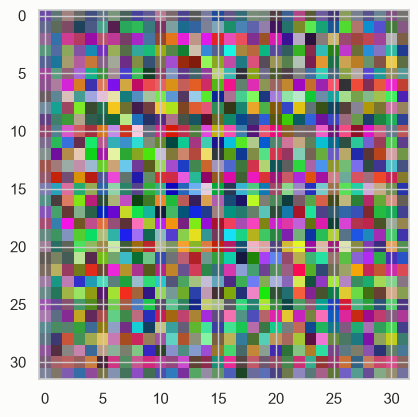

In [9]:
# Build the generator: concatenate noise vector with label, dense-expand, then transposed convs (strided, BatchNorm, ReLU) back to 32x32x3, tanh output.
gen = generator(128)
noise = torch.randn((64, 128))
label = next(iter(train_loader))['label']
test_gen_output = gen(noise, label)
print(test_gen_output.shape)
print(f'range: {test_gen_output.min().item()} ,{test_gen_output.max().item()}')
plt.imshow(F_t.to_pil_image(
    ((test_gen_output[0]+1)*127.5).to(torch.uint8)
))

## 5. Build the Conditional Discriminator

### 5.1 What It Does

The discriminator reshapes each one-hot label into 10 constant `32 x 32` maps and concatenates them with the three RGB channels, creating a 13-channel conditional input. Three stride-2 convolutions reduce the spatial resolution from `32 x 32` to `4 x 4`. LeakyReLU is applied after each convolution, BatchNorm is used after the second and third convolutions, and spatial dropout regularizes each convolutional block. The final feature map is flattened and mapped to one sigmoid real/fake probability.

The design follows the main DCGAN discriminator conventions used in this baseline:

* a single fully connected output layer after the convolutional feature extractor;
* BatchNorm after the non-input convolutional layers;
* LeakyReLU in the hidden layers and a sigmoid output; and
* strided convolutions instead of pooling layers.

In [10]:
train_data['label'][0].reshape(1, 10, 1, 1).expand(1, 10, 32, 32)
class discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 3, 2, 1) # 32x32 -> 16x16

        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1) # 16x16 -> 8x8
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1) # 8x8 -> 4x4
        self.bn3 = nn.BatchNorm2d(128)

        self.fc_out = nn.Linear(128*4*4, 1) 
        # activations
        
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

        # reg
        self.dropout2d = nn.Dropout2d(0.3)
        
    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)
        x = self.leakyrelu(self.conv1(x))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn2(self.conv2(x)))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn3(self.conv3(x)))
        x = self.dropout2d(x)
        x = x.flatten(start_dim=1)
        x = self.sigmoid(self.fc_out(x))
        return x

# i made this just to visualise the input channels:
# fig, ax = plt.subplots(1, 3)
# for i in range(3):
#     im = d(sample['img'], sample['label'])[0][i]
#     ax[i].imshow(F_t.to_pil_image(((im+1)*127.5).to(torch.uint8)), vmin=0, vmax=255)  
# plt.show()   
# fig, ax = plt.subplots(1, 10)
# for i in range(10):
#     im = d(sample['img'], sample['label'])[0][i+3]
#     ax[i].imshow(F_t.to_pil_image(((im+1)*127.5).to(torch.uint8)), vmin=0, vmax=255)  

# plt.show()

In [11]:
# Diagram: discriminator layer flow — image + label map -> concat -> strided conv stack (LeakyReLU) -> flatten -> dense -> real/fake logit.
d = discriminator()
sample = next(iter(train_loader))
test_disc_output = d(sample['img'], sample['label'])
print(test_disc_output.shape)
print(test_disc_output.T)

torch.Size([64, 1])
tensor([[0.5432, 0.4390, 0.5152, 0.4368, 0.3827, 0.6107, 0.5900, 0.5237, 0.4134,
         0.5737, 0.6623, 0.5076, 0.4119, 0.5475, 0.6882, 0.4306, 0.2966, 0.5311,
         0.3879, 0.7168, 0.5098, 0.5353, 0.6190, 0.4759, 0.5560, 0.3421, 0.4843,
         0.3390, 0.3607, 0.6088, 0.4971, 0.4752, 0.5031, 0.5064, 0.4445, 0.5556,
         0.6084, 0.2801, 0.5243, 0.5517, 0.6282, 0.4219, 0.5776, 0.6112, 0.4904,
         0.4976, 0.4510, 0.4530, 0.4529, 0.4381, 0.4919, 0.4813, 0.5827, 0.4733,
         0.6117, 0.5518, 0.5016, 0.4707, 0.4723, 0.6741, 0.3614, 0.5485, 0.4951,
         0.6273]], grad_fn=<PermuteBackward0>)


### 5.2 Implementation

This cell implements the baseline conditional discriminator without spectral normalization or other architectural extensions. The training objective also uses unsmoothed binary targets; spectral normalization and label smoothing are treated as separate experiments rather than baseline defaults.

In [12]:
# Build the discriminator: concatenate image with a broadcast label map, strided conv stack (LeakyReLU, dropout), flatten, dense to a single logit.

## 6. Define the GAN Training Step

### 6.1 Loss Formulation

Binary cross-entropy trains the discriminator to output 1 for real images and 0 for generated images, using unsmoothed targets in this baseline. The generator is then updated against a target of 1 for its generated images, forcing it to produce samples that the discriminator treats as real; real-discriminator loss, fake-discriminator loss, and generator loss are kept separate because their changing balance reveals adversarial stability more clearly than a single summed value.

### 6.2 Training loop Pseudocode

```
for e in range(epochs):
    for image, label in train_loader:
        
        generated_image = G(noise, label)

        freeze G
        train D

        # predict D(x) = 1
        pred = D(image, label)
        d_loss = criterion(pred, full_ones) # to predict real
        
        # predict D(G(z)) = 0
        pred = D(generated_image, label)
        d_loss = d_loss + criterion(pred, full_zeros)

        d_loss.backward()
        d_optim.step()

        freeze D
        train G

        # predict D(G(z)) = 1 -> update generator

        pred = D(generated_image, label)
        g_loss = criterion(pred, full_ones)

        g_loss.backward()
        g_optim.step()
```

### 6.3 Implementation

Both networks use binary cross-entropy with hard targets and separate Adam optimizers configured with the same learning rate of `0.0002`, so this baseline does not use a two-time-scale update rule (TTUR) or label smoothing. Those changes are evaluated separately in `gan_improvement.ipynb`.

The Adam coefficients are `betas=(0.5, 0.9)`. Relative to Adam's usual first-moment coefficient, the lower `beta_1` gives less weight to older gradient estimates, allowing the optimizer to respond more quickly to the continually changing adversarial objective.

In [13]:
# Define the GAN keras.Model subclass with a custom train_step implementing the alternating generator/discriminator updates above.
noise_dim = 128
bs = 128
validation_n_samples=5
classes  = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

G = generator(noise_dim).to(device)

D = discriminator().to(device)

g_lr = 0.0002
d_lr = 0.0002

g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))

criterion = nn.BCELoss()
cpu_cores=8
train_loader = DataLoader(train_data, batch_size=bs, shuffle=True)
train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True,
    num_workers=cpu_cores,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)
val_loader = DataLoader(val_data, batch_size=bs, shuffle=True, drop_last=True) # this is about 5k but the last small batch is removed
val_loader = DataLoader(
    val_data,
    batch_size=128,
    shuffle=True,
    num_workers=cpu_cores,
    drop_last=True,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)
epochs = 50

def set_requires_grad(model, yesno):
    for param in model.parameters():
        param.requires_grad_(yesno)

def print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss):
    print(f'D(x) = {D_x:.4f}')
    print(f'D(G(z)) = {D_Gz:.4f}')
    print(f'D Loss (real): {real_d_loss:.3f} | D Loss (fake): {fake_d_loss:.3f}')
    print(f'Generator Loss: {g_loss:.3f}')

val_noise = torch.randn((bs, noise_dim)).to(device)
D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

def track_metrics(train_val, D_x, D_Gz, real_d_loss, fake_d_loss, g_loss):
    D_x_track[train_val].append(D_x.item())
    D_Gz_track[train_val].append(D_Gz.item())
    real_d_loss_track[train_val].append(real_d_loss.item())
    fake_d_loss_track[train_val].append(fake_d_loss.item())
    g_loss_track[train_val].append(g_loss.item())

fixed_noise_progression_grid = {}


def generate_class_images(G, n, e):
    G.eval()
    fixed_noise_progression_grid[e + 1] = []

    with torch.no_grad():
        fig, ax = plt.subplots(n, 10, figsize=(12, 5))
        for col, a in enumerate(ax[0]):
            a.set_title(f"{classes[col]}", pad=10)

        for idx in range(10):
            one_hot_label = [0] * 10
            one_hot_label[idx] = 1
            one_hot_label = torch.Tensor(one_hot_label).expand(n, -1).to(device)
            noise = val_noise[0:n].to(device)
            per_class_generated_imgs = G(noise, one_hot_label)

            fixed_noise_progression_grid[e + 1].append(
                per_class_generated_imgs[0].detach().cpu().numpy()
            )

            for img in range(per_class_generated_imgs.size(0)):
                ax[img][idx].imshow(F_t.to_pil_image(
                    (127.5 * (per_class_generated_imgs[img] + 1)).to(torch.uint8)
                ))
                ax[img][idx].axis("off")

        plt.tight_layout()
        plt.show()


## 7. Train the Model

### 7.1 Fit and Save Final Weights

The generator and discriminator are trained alternately for 50 epochs. Training and validation diagnostics are recorded after each epoch, and fixed-noise samples are generated every five epochs. Because neither generator loss nor discriminator loss alone defines a uniquely best GAN checkpoint, the code saves the final generator and discriminator states as `baseline_g.pt` and `baseline_d.pt`. The subsequent progression, diversity, class-conditioning, and nearest-neighbour analyses are therefore diagnostic evaluations of this final baseline rather than checkpoint-selection criteria.



Epoch 0

D(x) = 0.5620
D(G(z)) = 0.3795
D Loss (real): 0.910 | D Loss (fake): 0.577
Generator Loss: 1.207
== Validation ==
D(x) = 0.6414
D(G(z)) = 0.4944
D Loss (real): 0.487 | D Loss (fake): 0.709
Generator Loss: 0.736


Epoch 1

D(x) = 0.5662
D(G(z)) = 0.3470
D Loss (real): 0.521 | D Loss (fake): 0.570
Generator Loss: 1.174
== Validation ==
D(x) = 0.5534
D(G(z)) = 0.4449
D Loss (real): 0.612 | D Loss (fake): 0.600
Generator Loss: 0.832


Epoch 2

D(x) = 0.5420
D(G(z)) = 0.3495
D Loss (real): 0.665 | D Loss (fake): 0.638
Generator Loss: 1.164
== Validation ==
D(x) = 0.5461
D(G(z)) = 0.4694
D Loss (real): 0.630 | D Loss (fake): 0.646
Generator Loss: 0.772


Epoch 3

D(x) = 0.6268
D(G(z)) = 0.2435
D Loss (real): 0.468 | D Loss (fake): 0.503
Generator Loss: 1.755
== Validation ==
D(x) = 0.6255
D(G(z)) = 0.3494
D Loss (real): 0.506 | D Loss (fake): 0.450
Generator Loss: 1.126


Epoch 4

D(x) = 0.7268
D(G(z)) = 0.2238
D Loss (real): 0.463 | D Loss (fake): 0.372
Generator Loss: 1.879
== V

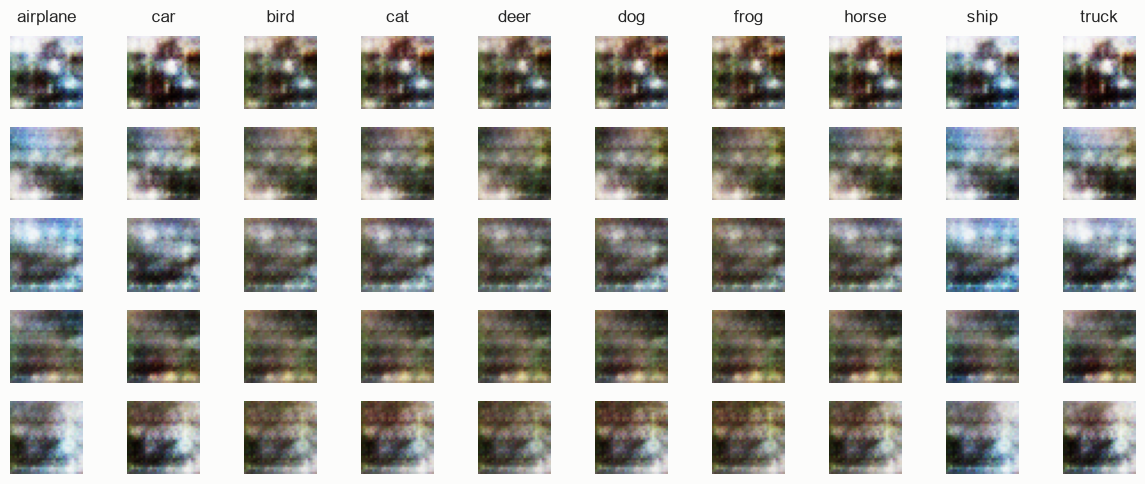



Epoch 5

D(x) = 0.6445
D(G(z)) = 0.3291
D Loss (real): 0.516 | D Loss (fake): 0.613
Generator Loss: 1.440
== Validation ==
D(x) = 0.5911
D(G(z)) = 0.3077
D Loss (real): 0.588 | D Loss (fake): 0.389
Generator Loss: 1.301


Epoch 6

D(x) = 0.6818
D(G(z)) = 0.2275
D Loss (real): 0.623 | D Loss (fake): 0.348
Generator Loss: 1.894
== Validation ==
D(x) = 0.6093
D(G(z)) = 0.3183
D Loss (real): 0.529 | D Loss (fake): 0.399
Generator Loss: 1.212


Epoch 7

D(x) = 0.6657
D(G(z)) = 0.3499
D Loss (real): 0.406 | D Loss (fake): 0.696
Generator Loss: 1.269
== Validation ==
D(x) = 0.6133
D(G(z)) = 0.4331
D Loss (real): 0.523 | D Loss (fake): 0.591
Generator Loss: 0.877


Epoch 8

D(x) = 0.6212
D(G(z)) = 0.3305
D Loss (real): 0.699 | D Loss (fake): 0.715
Generator Loss: 1.413
== Validation ==
D(x) = 0.5924
D(G(z)) = 0.3811
D Loss (real): 0.564 | D Loss (fake): 0.498
Generator Loss: 1.024


Epoch 9

D(x) = 0.6775
D(G(z)) = 0.3841
D Loss (real): 0.507 | D Loss (fake): 0.390
Generator Loss: 1.169
== V

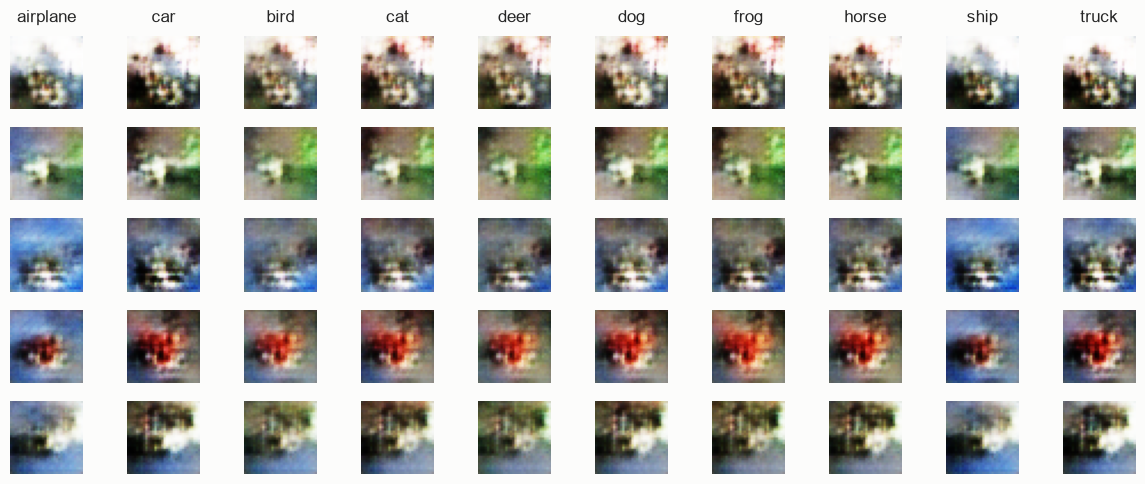



Epoch 10

D(x) = 0.6379
D(G(z)) = 0.2345
D Loss (real): 0.544 | D Loss (fake): 0.523
Generator Loss: 1.929
== Validation ==
D(x) = 0.5565
D(G(z)) = 0.2821
D Loss (real): 0.626 | D Loss (fake): 0.342
Generator Loss: 1.342


Epoch 11

D(x) = 0.6270
D(G(z)) = 0.2516
D Loss (real): 0.251 | D Loss (fake): 0.635
Generator Loss: 1.699
== Validation ==
D(x) = 0.6015
D(G(z)) = 0.2575
D Loss (real): 0.548 | D Loss (fake): 0.307
Generator Loss: 1.431


Epoch 12

D(x) = 0.6917
D(G(z)) = 0.2763
D Loss (real): 0.424 | D Loss (fake): 0.495
Generator Loss: 1.663
== Validation ==
D(x) = 0.5831
D(G(z)) = 0.3102
D Loss (real): 0.570 | D Loss (fake): 0.389
Generator Loss: 1.262


Epoch 13

D(x) = 0.6727
D(G(z)) = 0.3112
D Loss (real): 0.496 | D Loss (fake): 0.493
Generator Loss: 1.454
== Validation ==
D(x) = 0.6266
D(G(z)) = 0.3321
D Loss (real): 0.501 | D Loss (fake): 0.419
Generator Loss: 1.174


Epoch 14

D(x) = 0.6648
D(G(z)) = 0.2027
D Loss (real): 0.356 | D Loss (fake): 0.460
Generator Loss: 2.005

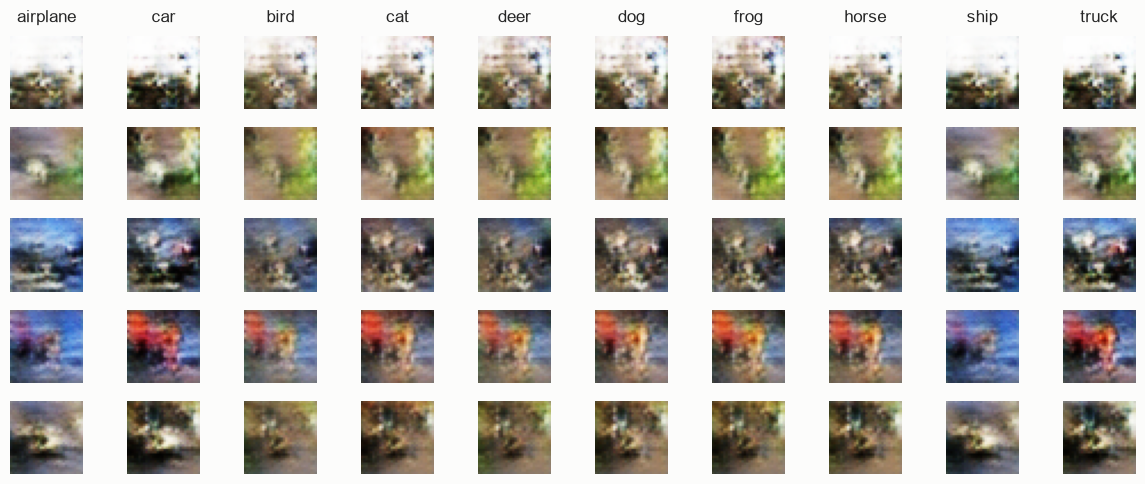



Epoch 15

D(x) = 0.5962
D(G(z)) = 0.2787
D Loss (real): 0.653 | D Loss (fake): 0.384
Generator Loss: 1.582
== Validation ==
D(x) = 0.6320
D(G(z)) = 0.3237
D Loss (real): 0.485 | D Loss (fake): 0.409
Generator Loss: 1.208


Epoch 16

D(x) = 0.7175
D(G(z)) = 0.2980
D Loss (real): 0.440 | D Loss (fake): 0.349
Generator Loss: 1.637
== Validation ==
D(x) = 0.6248
D(G(z)) = 0.3412
D Loss (real): 0.497 | D Loss (fake): 0.430
Generator Loss: 1.130


Epoch 17

D(x) = 0.7604
D(G(z)) = 0.3566
D Loss (real): 0.765 | D Loss (fake): 0.465
Generator Loss: 1.280
== Validation ==
D(x) = 0.6360
D(G(z)) = 0.3904
D Loss (real): 0.474 | D Loss (fake): 0.514
Generator Loss: 0.987


Epoch 18

D(x) = 0.6501
D(G(z)) = 0.3372
D Loss (real): 0.765 | D Loss (fake): 0.447
Generator Loss: 1.326
== Validation ==
D(x) = 0.6101
D(G(z)) = 0.3482
D Loss (real): 0.518 | D Loss (fake): 0.445
Generator Loss: 1.129


Epoch 19

D(x) = 0.5993
D(G(z)) = 0.2696
D Loss (real): 0.299 | D Loss (fake): 0.766
Generator Loss: 1.614

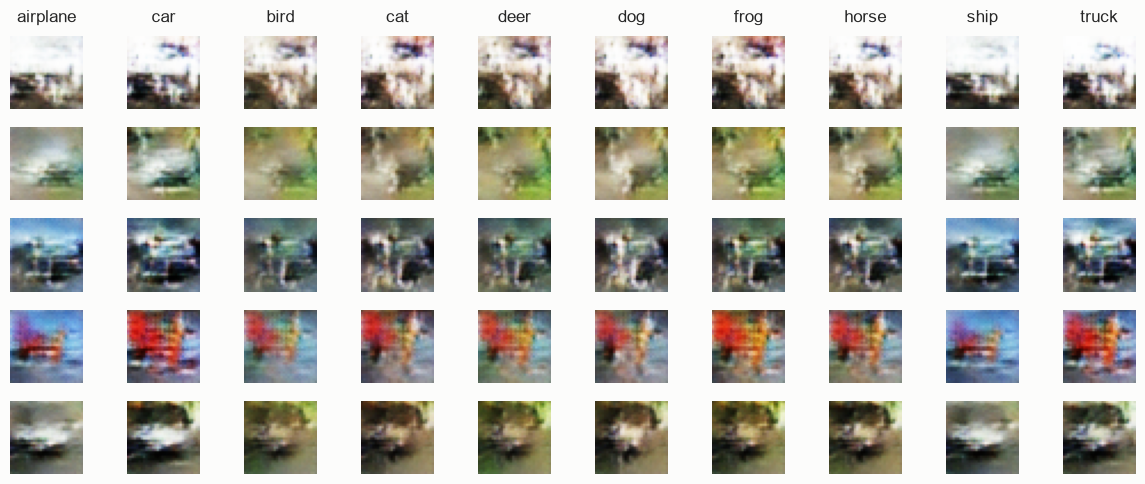



Epoch 20

D(x) = 0.6503
D(G(z)) = 0.2826
D Loss (real): 0.527 | D Loss (fake): 0.397
Generator Loss: 1.479
== Validation ==
D(x) = 0.5744
D(G(z)) = 0.3746
D Loss (real): 0.580 | D Loss (fake): 0.480
Generator Loss: 1.015


Epoch 21

D(x) = 0.6446
D(G(z)) = 0.3213
D Loss (real): 0.447 | D Loss (fake): 0.566
Generator Loss: 1.334
== Validation ==
D(x) = 0.5552
D(G(z)) = 0.3906
D Loss (real): 0.623 | D Loss (fake): 0.515
Generator Loss: 0.985


Epoch 22

D(x) = 0.6583
D(G(z)) = 0.4772
D Loss (real): 0.507 | D Loss (fake): 0.574
Generator Loss: 0.848
== Validation ==
D(x) = 0.6193
D(G(z)) = 0.4169
D Loss (real): 0.495 | D Loss (fake): 0.558
Generator Loss: 0.919


Epoch 23

D(x) = 0.5283
D(G(z)) = 0.3841
D Loss (real): 0.654 | D Loss (fake): 0.505
Generator Loss: 1.185
== Validation ==
D(x) = 0.5831
D(G(z)) = 0.3462
D Loss (real): 0.562 | D Loss (fake): 0.438
Generator Loss: 1.108


Epoch 24

D(x) = 0.6090
D(G(z)) = 0.4462
D Loss (real): 0.404 | D Loss (fake): 0.636
Generator Loss: 0.949

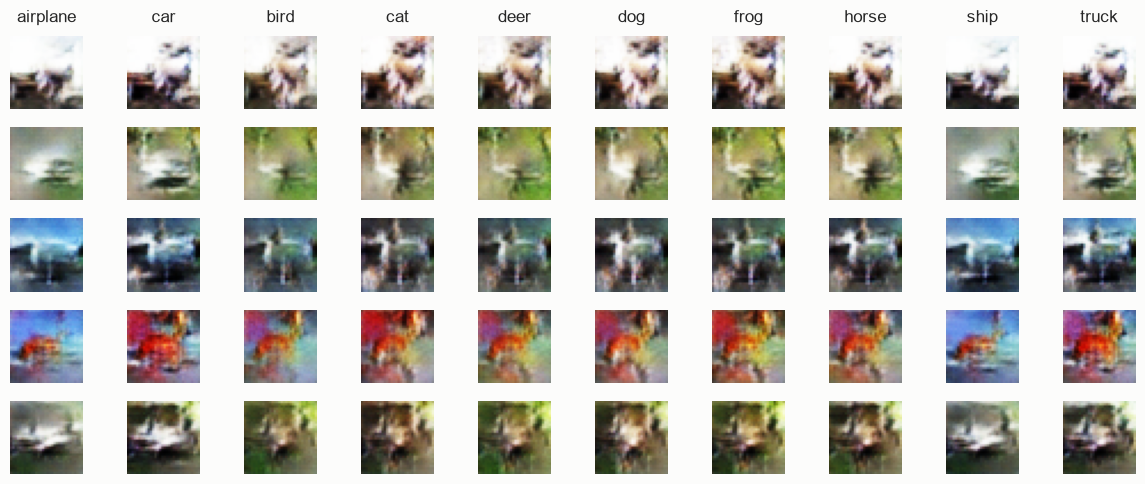



Epoch 25

D(x) = 0.6444
D(G(z)) = 0.4669
D Loss (real): 0.854 | D Loss (fake): 0.380
Generator Loss: 0.933
== Validation ==
D(x) = 0.5671
D(G(z)) = 0.3977
D Loss (real): 0.590 | D Loss (fake): 0.522
Generator Loss: 0.959


Epoch 26

D(x) = 0.5735
D(G(z)) = 0.3195
D Loss (real): 0.512 | D Loss (fake): 0.628
Generator Loss: 1.346
== Validation ==
D(x) = 0.5413
D(G(z)) = 0.3669
D Loss (real): 0.635 | D Loss (fake): 0.469
Generator Loss: 1.049


Epoch 27

D(x) = 0.6321
D(G(z)) = 0.4246
D Loss (real): 0.574 | D Loss (fake): 0.392
Generator Loss: 1.029
== Validation ==
D(x) = 0.5855
D(G(z)) = 0.4022
D Loss (real): 0.558 | D Loss (fake): 0.530
Generator Loss: 0.953


Epoch 28

D(x) = 0.6861
D(G(z)) = 0.5278
D Loss (real): 0.642 | D Loss (fake): 0.307
Generator Loss: 0.775
== Validation ==
D(x) = 0.6049
D(G(z)) = 0.4169
D Loss (real): 0.520 | D Loss (fake): 0.559
Generator Loss: 0.931


Epoch 29

D(x) = 0.7027
D(G(z)) = 0.4086
D Loss (real): 0.421 | D Loss (fake): 0.486
Generator Loss: 1.104

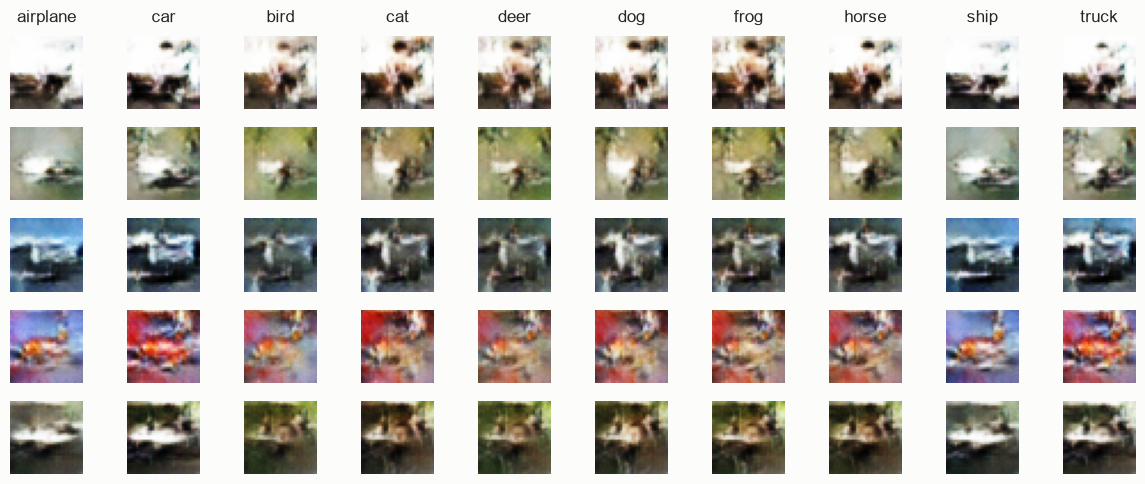



Epoch 30

D(x) = 0.6256
D(G(z)) = 0.3841
D Loss (real): 0.438 | D Loss (fake): 0.684
Generator Loss: 1.124
== Validation ==
D(x) = 0.5866
D(G(z)) = 0.4377
D Loss (real): 0.551 | D Loss (fake): 0.591
Generator Loss: 0.853


Epoch 31

D(x) = 0.6491
D(G(z)) = 0.3408
D Loss (real): 0.542 | D Loss (fake): 0.347
Generator Loss: 1.305
== Validation ==
D(x) = 0.6086
D(G(z)) = 0.4294
D Loss (real): 0.516 | D Loss (fake): 0.574
Generator Loss: 0.871


Epoch 32

D(x) = 0.5952
D(G(z)) = 0.2880
D Loss (real): 0.519 | D Loss (fake): 0.457
Generator Loss: 1.530
== Validation ==
D(x) = 0.5338
D(G(z)) = 0.3960
D Loss (real): 0.648 | D Loss (fake): 0.521
Generator Loss: 0.970


Epoch 33

D(x) = 0.6478
D(G(z)) = 0.2883
D Loss (real): 0.457 | D Loss (fake): 0.446
Generator Loss: 1.538
== Validation ==
D(x) = 0.5645
D(G(z)) = 0.3937
D Loss (real): 0.596 | D Loss (fake): 0.520
Generator Loss: 0.990


Epoch 34

D(x) = 0.6061
D(G(z)) = 0.2887
D Loss (real): 0.399 | D Loss (fake): 0.742
Generator Loss: 1.463

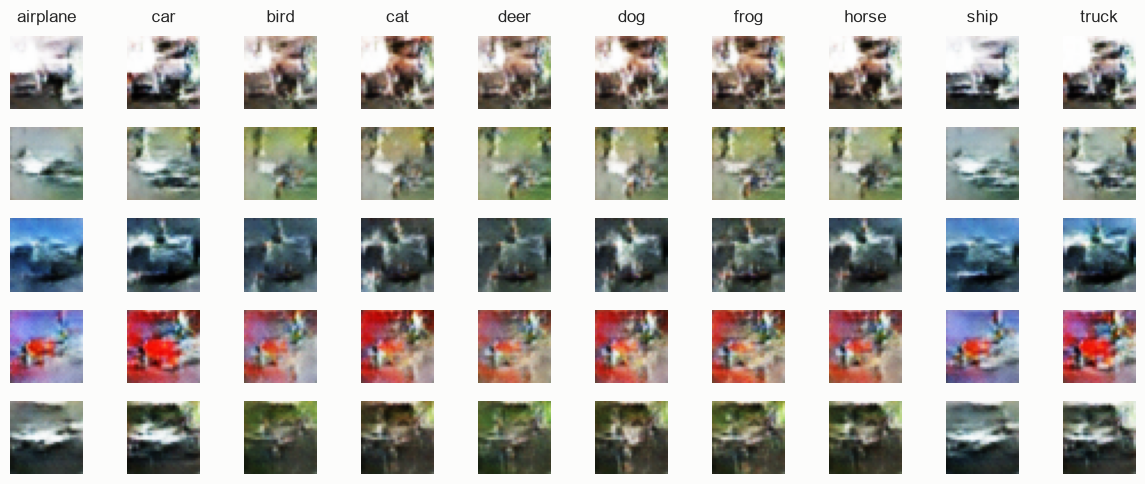



Epoch 35

D(x) = 0.7237
D(G(z)) = 0.4565
D Loss (real): 0.732 | D Loss (fake): 0.533
Generator Loss: 0.945
== Validation ==
D(x) = 0.6299
D(G(z)) = 0.4392
D Loss (real): 0.475 | D Loss (fake): 0.598
Generator Loss: 0.863


Epoch 36

D(x) = 0.5894
D(G(z)) = 0.2878
D Loss (real): 0.466 | D Loss (fake): 0.499
Generator Loss: 1.508
== Validation ==
D(x) = 0.5892
D(G(z)) = 0.4070
D Loss (real): 0.547 | D Loss (fake): 0.541
Generator Loss: 0.952


Epoch 37

D(x) = 0.6567
D(G(z)) = 0.4845
D Loss (real): 0.659 | D Loss (fake): 0.587
Generator Loss: 0.821
== Validation ==
D(x) = 0.6643
D(G(z)) = 0.4825
D Loss (real): 0.416 | D Loss (fake): 0.683
Generator Loss: 0.766


Epoch 38

D(x) = 0.6274
D(G(z)) = 0.3115
D Loss (real): 0.739 | D Loss (fake): 0.720
Generator Loss: 1.366
== Validation ==
D(x) = 0.5630
D(G(z)) = 0.4367
D Loss (real): 0.591 | D Loss (fake): 0.589
Generator Loss: 0.856


Epoch 39

D(x) = 0.5836
D(G(z)) = 0.3852
D Loss (real): 0.535 | D Loss (fake): 0.465
Generator Loss: 1.169

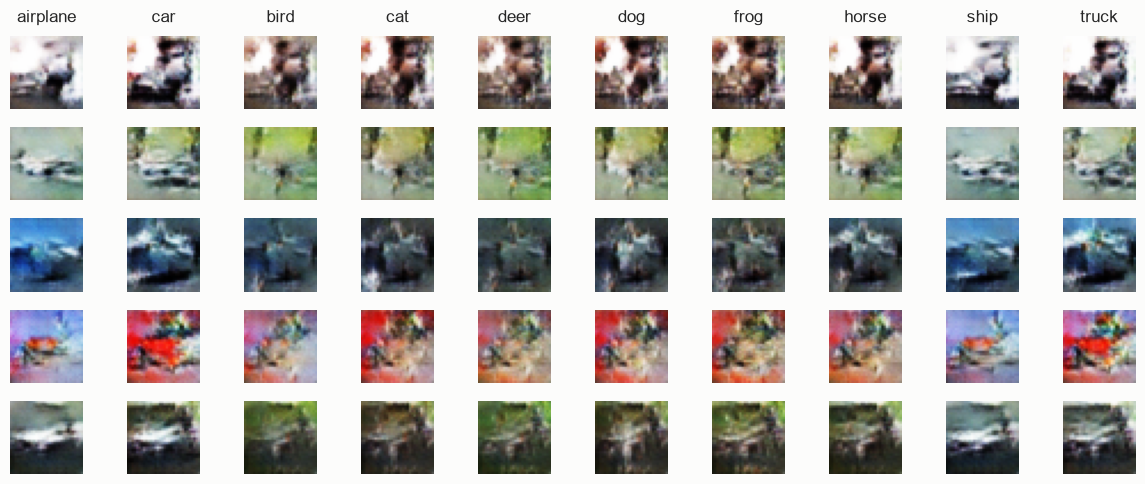



Epoch 40

D(x) = 0.6562
D(G(z)) = 0.4671
D Loss (real): 0.596 | D Loss (fake): 0.356
Generator Loss: 0.902
== Validation ==
D(x) = 0.6359
D(G(z)) = 0.4428
D Loss (real): 0.468 | D Loss (fake): 0.600
Generator Loss: 0.842


Epoch 41

D(x) = 0.5056
D(G(z)) = 0.3182
D Loss (real): 0.654 | D Loss (fake): 0.381
Generator Loss: 1.311
== Validation ==
D(x) = 0.6098
D(G(z)) = 0.4479
D Loss (real): 0.507 | D Loss (fake): 0.612
Generator Loss: 0.835


Epoch 42

D(x) = 0.7554
D(G(z)) = 0.4166
D Loss (real): 0.403 | D Loss (fake): 0.647
Generator Loss: 1.037
== Validation ==
D(x) = 0.6213
D(G(z)) = 0.4686
D Loss (real): 0.488 | D Loss (fake): 0.649
Generator Loss: 0.782


Epoch 43

D(x) = 0.7092
D(G(z)) = 0.5933
D Loss (real): 0.649 | D Loss (fake): 0.418
Generator Loss: 0.592
== Validation ==
D(x) = 0.6633
D(G(z)) = 0.5147
D Loss (real): 0.422 | D Loss (fake): 0.748
Generator Loss: 0.689


Epoch 44

D(x) = 0.5236
D(G(z)) = 0.3067
D Loss (real): 0.390 | D Loss (fake): 0.346
Generator Loss: 1.355

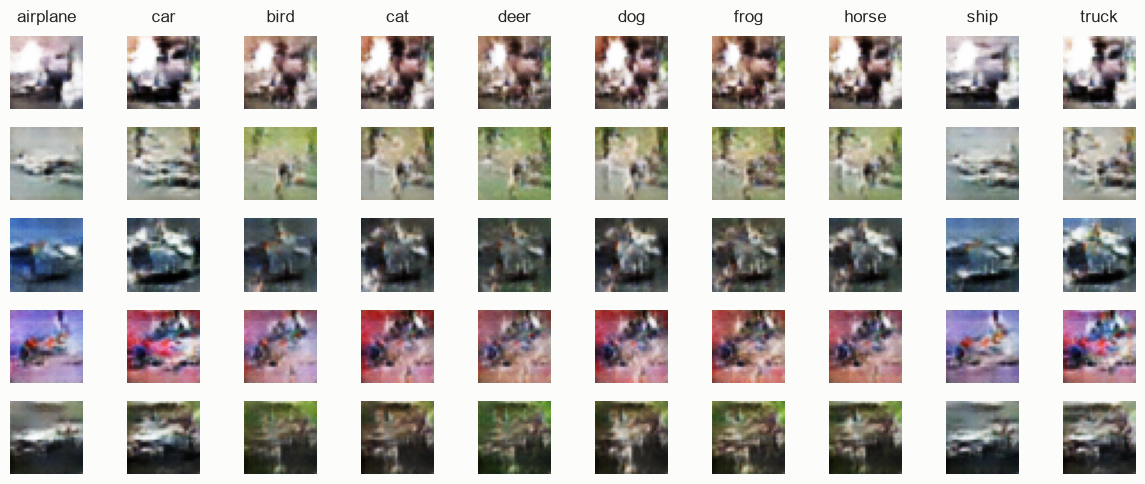



Epoch 45

D(x) = 0.7445
D(G(z)) = 0.3537
D Loss (real): 0.511 | D Loss (fake): 0.463
Generator Loss: 1.290
== Validation ==
D(x) = 0.5797
D(G(z)) = 0.4221
D Loss (real): 0.567 | D Loss (fake): 0.563
Generator Loss: 0.896


Epoch 46

D(x) = 0.6692
D(G(z)) = 0.3659
D Loss (real): 0.590 | D Loss (fake): 0.582
Generator Loss: 1.164
== Validation ==
D(x) = 0.6106
D(G(z)) = 0.4545
D Loss (real): 0.505 | D Loss (fake): 0.623
Generator Loss: 0.816


Epoch 47

D(x) = 0.5946
D(G(z)) = 0.4099
D Loss (real): 0.590 | D Loss (fake): 0.737
Generator Loss: 1.058
== Validation ==
D(x) = 0.6160
D(G(z)) = 0.4757
D Loss (real): 0.496 | D Loss (fake): 0.660
Generator Loss: 0.762


Epoch 48

D(x) = 0.7067
D(G(z)) = 0.3490
D Loss (real): 0.768 | D Loss (fake): 0.498
Generator Loss: 1.210
== Validation ==
D(x) = 0.5941
D(G(z)) = 0.4235
D Loss (real): 0.536 | D Loss (fake): 0.564
Generator Loss: 0.886


Epoch 49

D(x) = 0.6703
D(G(z)) = 0.4330
D Loss (real): 0.840 | D Loss (fake): 0.561
Generator Loss: 1.009

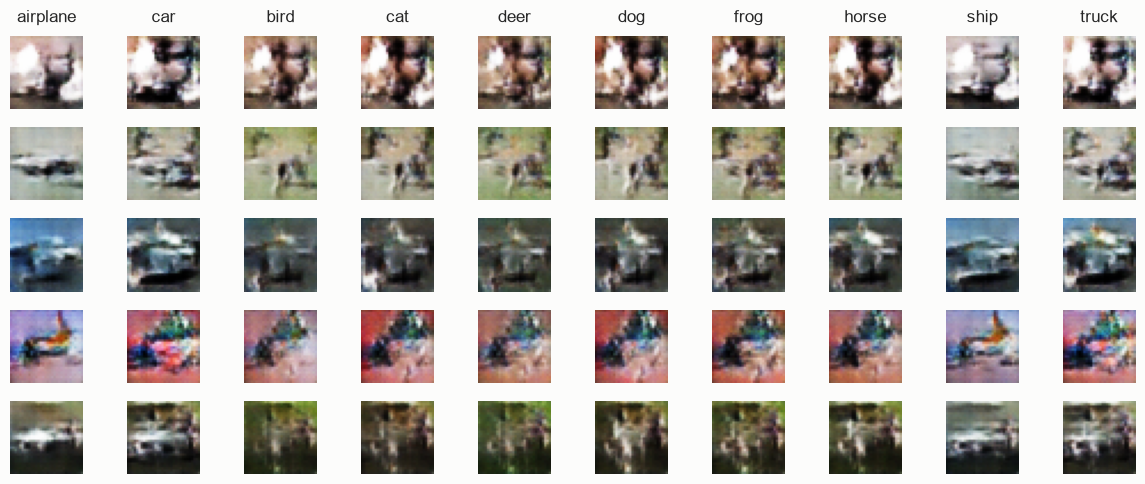

In [14]:
# Compile and fit the GAN for a fixed number of epochs, saving the generator's weights to a .h5 checkpoint at the end.
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
        set_requires_grad(D, True)

        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    if (e+1)%5 == 0:
        generate_class_images(G, validation_n_samples, e)


In [15]:
torch.save(G.state_dict(), 'baseline_g.pt')
torch.save(D.state_dict(), 'baseline_d.pt')

### 7.2 Loss Curves

The chart overlays the recorded training and validation histories for real-image discriminator loss, generated-image discriminator loss, and generator loss. GAN losses are expected to oscillate because each network is optimizing against an opponent that is also changing. In this implementation, however, each plotted point is taken from the final minibatch of its epoch rather than averaged over every minibatch. The curves should therefore be interpreted as coarse snapshots of adversarial dynamics, not as precise epoch-level loss estimates.

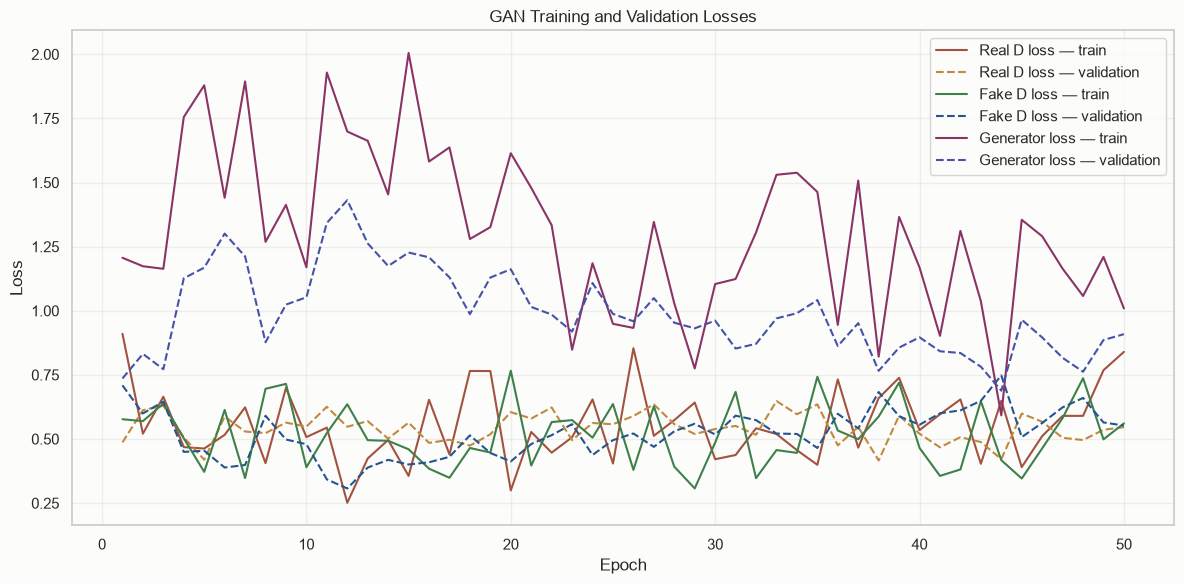

In [16]:
# Plot generator loss and discriminator loss on the same axes across training epochs.
def plot_combined_gan_losses(
    real_d_loss_track,
    fake_d_loss_track,
    g_loss_track,
):
    plt.figure(figsize=(12, 6))

    tracks = {
        "Real D loss": real_d_loss_track,
        "Fake D loss": fake_d_loss_track,
        "Generator loss": g_loss_track,
    }

    for label, track in tracks.items():
        train_values = track.get("train", [])
        val_values = track.get("val", [])

        if train_values:
            plt.plot(
                range(1, len(train_values) + 1),
                train_values,
                label=f"{label} — train",
            )

        if val_values:
            plt.plot(
                range(1, len(val_values) + 1),
                val_values,
                linestyle="--",
                label=f"{label} — validation",
            )

    plt.title("GAN Training and Validation Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_combined_gan_losses(
    real_d_loss_track,
    fake_d_loss_track,
    g_loss_track,
)

### Conclusion: 

At the end of epoch 50, the final recorded training-batch losses were `1.009` for the generator, `0.840` for the discriminator on real images, and `0.561` for the discriminator on generated images. The corresponding final validation-batch losses were `0.909`, `0.546`, and `0.552`; the validation predictions averaged `D(x) = 0.5869` for real images and `D(G(z)) = 0.4159` for generated images. Across the run, all three curves fluctuated substantially but neither discriminator loss remained near zero and the generator loss did not diverge for a sustained period. This is consistent with continued adversarial competition, but it does not demonstrate convergence or high image quality. Moreover, because the recorded values come from only the final minibatch of each epoch, the loss curves should be treated as supporting diagnostics rather than definitive performance measurements.

## 8. Diagnostics

### 8.1 Fixed-Noise Progression Grid

`val_noise` is created once and reused whenever a snapshot is taken. Every five epochs, the generator receives the same latent vectors paired with each of the 10 class labels; the summary grid displays the first resulting image for each class. Consequently, changes down a column primarily reflect changes in learned weights, while differences across columns show how changing the requested class affects a fixed latent input. This controlled comparison makes broad improvements, deterioration, and cross-class similarity easier to identify.

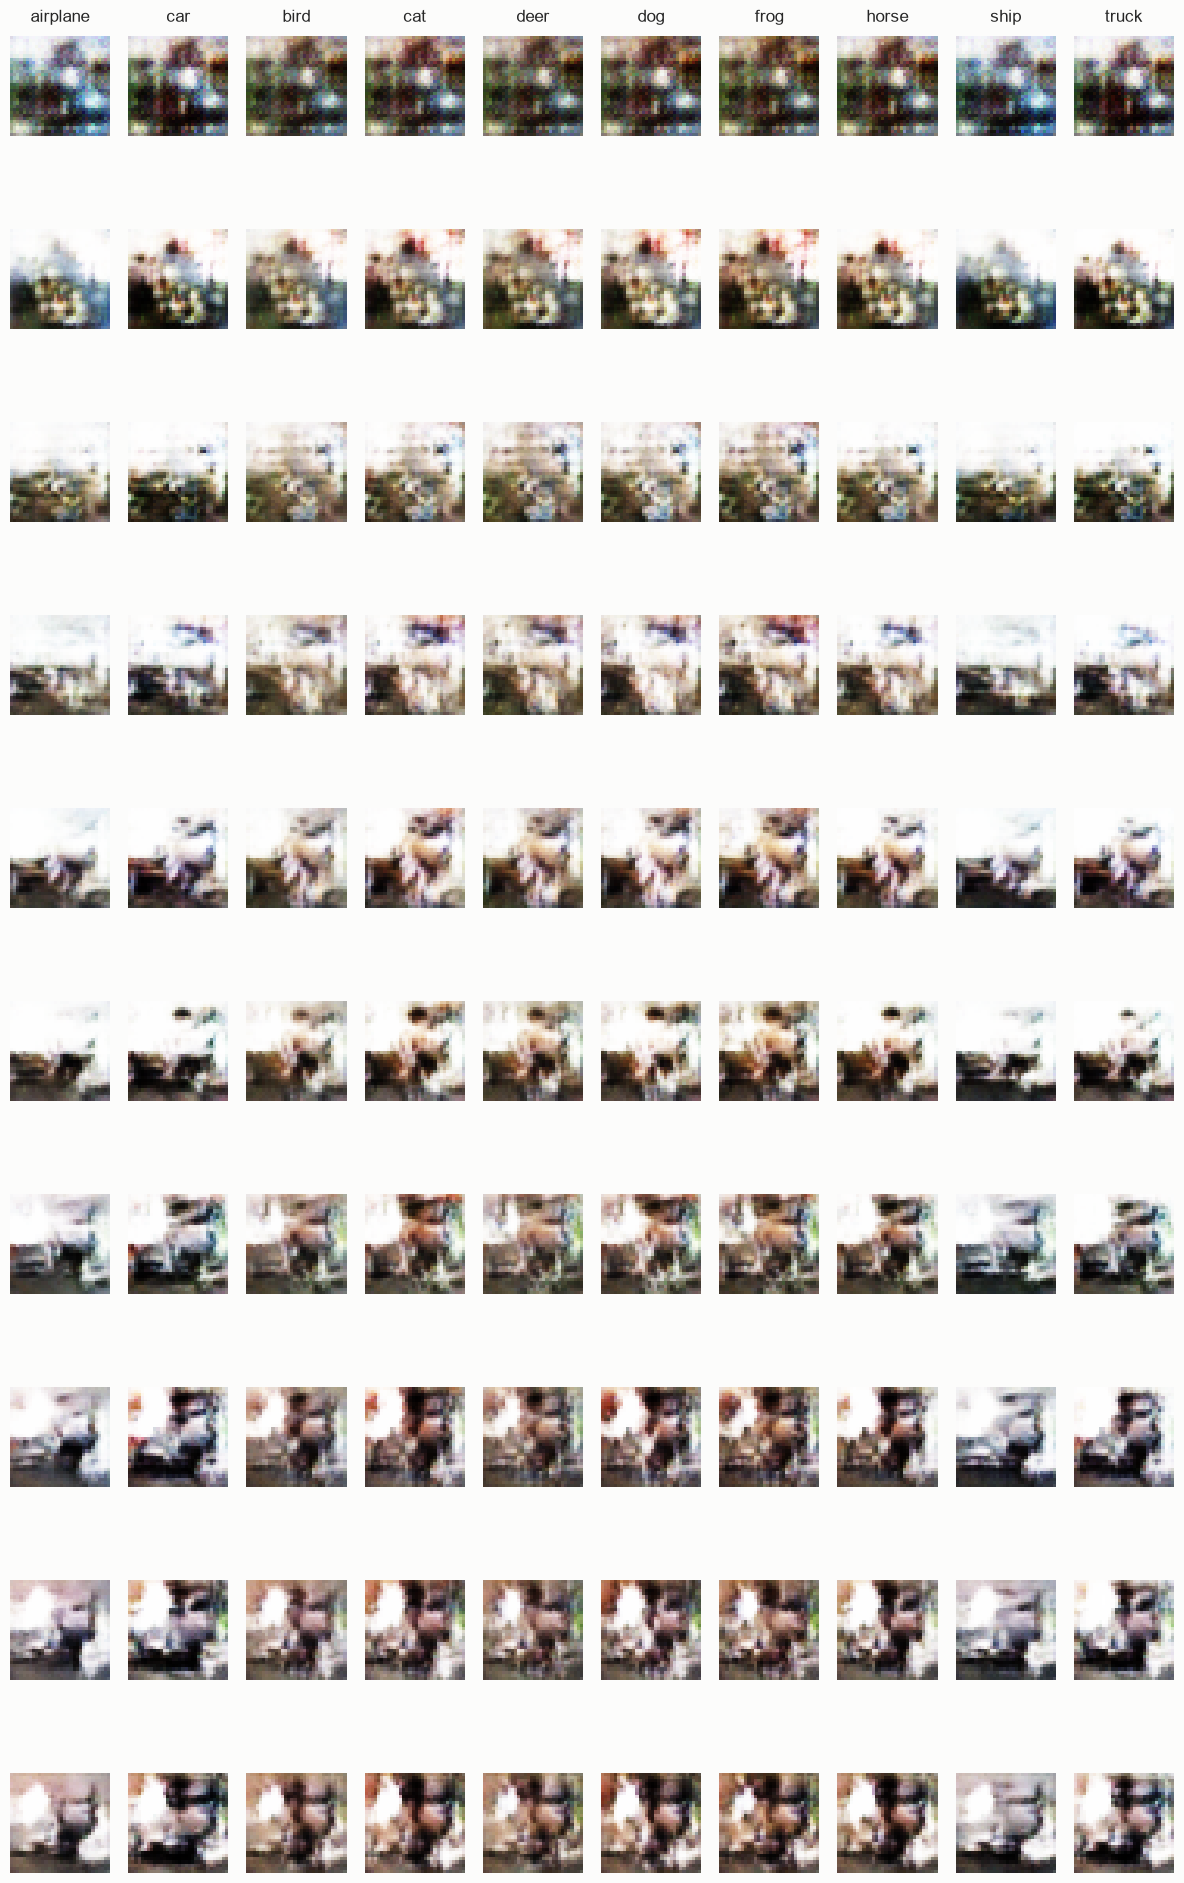

In [17]:
# Generate images from a fixed noise+label batch every N epochs during training; display the saved snapshots as a progression grid.
def plot_fixed_noise_progression_grid(fixed_noise_progression_grid):
    fig, ax = plt.subplots(
        len(fixed_noise_progression_grid),
        10,
        figsize=(12, 2 * len(fixed_noise_progression_grid))
    )

    for col, a in enumerate(ax[0]):
        a.set_title(f"{classes[col]}", pad=10)

    for row, key in enumerate(fixed_noise_progression_grid):
        ax[row][0].set_ylabel(
            f"epoch {key}",
            rotation=0,
            labelpad=35,
            va="center"
        )

        for idx in range(10):
            generated_img = fixed_noise_progression_grid[key][idx]

            generated_img = torch.tensor(generated_img)

            ax[row][idx].imshow(
                F_t.to_pil_image(
                    (127.5 * (generated_img + 1)).to(torch.uint8)
                )
            )
            ax[row][idx].axis("off")

    plt.tight_layout()
    plt.show()
plot_fixed_noise_progression_grid(fixed_noise_progression_grid)

### Conclusion: 

Across the saved snapshots from epochs 5 to 50, the outputs move from diffuse colour regions toward more coherent object-like silhouettes and backgrounds, with the clearest structural development occurring by approximately epochs 20–40. The final rows remain visibly blurred, and several animal classes retain very similar compositions despite receiving different labels. Vehicle and ship columns show somewhat more distinct colour or background cues, but the grid does not show strong separation across all 10 classes. The progression therefore supports that the generator learned coarse CIFAR10 structure, while the persistent cross-class similarity suggests weak use of the conditioning label. Because the grid shows only one fixed latent example per class at each checkpoint, it is a qualitative diagnostic rather than a complete measure of class fidelity.

### 8.2 Within-class Mode Collapse Quantification

Within-class variation is assessed by generating 128 images for each class from independently sampled 128-dimensional Gaussian noise vectors while holding the one-hot class label fixed. For each class, the standard deviation is computed at every pixel and channel and then averaged into one diversity score. The same statistic is calculated from real validation images for comparison. A substantially lower generated score would be consistent with reduced pixel-level variation, but a similar or higher score does not by itself prove semantic diversity because noise and visual artifacts can also increase pixel variance.

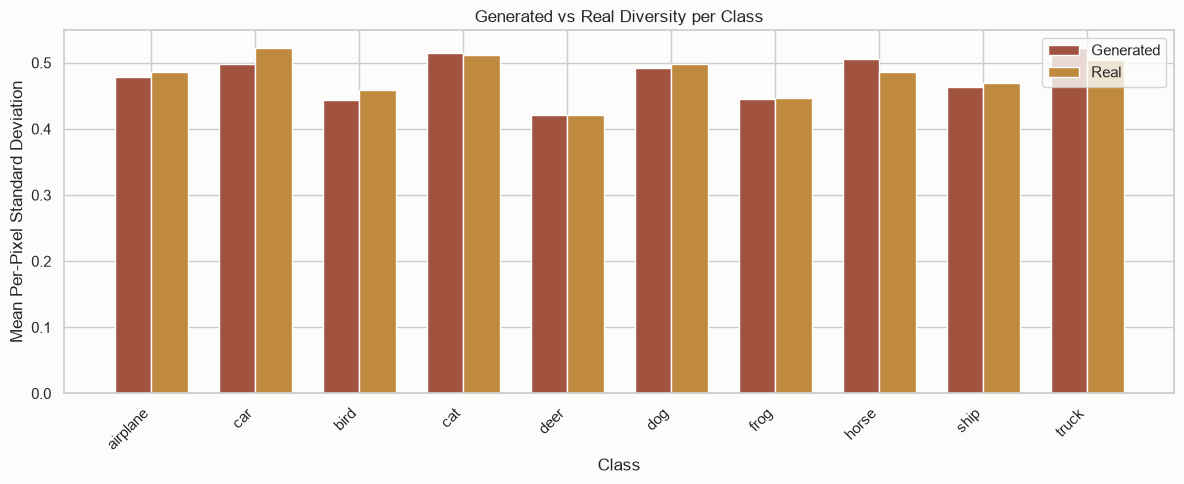

In [18]:
def compare_generated_real_diversity(G, val_loader, classes, noise_dim, device, n_generated_samples=128):
    class_images = {idx: [] for idx in range(len(classes))}

    # Real-image diversity
    for batch in val_loader:
        images = batch["img"]
        labels = batch["label"]

        class_indices = labels.squeeze(-1).argmax(dim=1)

        for img, class_idx in zip(images, class_indices):
            class_images[class_idx.item()].append(img)

    real_diversity_scores = {}

    for class_idx, class_name in enumerate(classes):
        images = torch.stack(class_images[class_idx])
        real_diversity_scores[class_name] = images.std(dim=0).mean().item()

    # Generated-image diversity
    generated_diversity_scores = {}

    G.eval()

    with torch.no_grad():
        for class_idx, class_name in enumerate(classes):
            noise = torch.randn(n_generated_samples, noise_dim, device=device)
            one_hot_labels = torch.zeros(n_generated_samples, len(classes), device=device)
            one_hot_labels[:, class_idx] = 1

            generated_images = G(noise, one_hot_labels)
            generated_diversity_scores[class_name] = generated_images.std(dim=0).mean().item()

    # Grouped vertical bar chart
    generated_values = [generated_diversity_scores[class_name] for class_name in classes]
    real_values = [real_diversity_scores[class_name] for class_name in classes]

    x = torch.arange(len(classes)).numpy()
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width / 2, generated_values, width, label="Generated")
    ax.bar(x + width / 2, real_values, width, label="Real")

    ax.set_title("Generated vs Real Diversity per Class")
    ax.set_xlabel("Class")
    ax.set_ylabel("Mean Per-Pixel Standard Deviation")
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return generated_diversity_scores, real_diversity_scores
generated_scores, real_scores = compare_generated_real_diversity(G=G,val_loader=val_loader,classes=classes,noise_dim=noise_dim,device=device,n_generated_samples=128)

**Observed result.** The generated and real bars are close for every class, and the broad class-to-class pattern is similar. The largest visible generated-versus-real shortfall occurs for car, whereas cat, horse, and truck have generated diversity that is approximately equal to or slightly greater than the corresponding real-image score. These comparisons concern pixel-level dispersion only and should not be interpreted as proof that the images occupy distinct semantic modes.

### Conclusion: 

No class shows a large reduction in mean per-pixel standard deviation relative to real validation images. On this specific statistic, there is therefore no evidence of severe within-class collapse to nearly identical pixel outputs. This conclusion is deliberately limited: comparable pixel variance can coexist with repeated semantic content, background variation, or noisy artifacts, so the result should be considered alongside the fixed-noise grid, class-conditioning NMI, and visual inspection.

### 8.3 Between-Class Conditioning Quantification

To measure whether generated outputs change systematically with the requested class, every label in the 10,000-image CIFAR10 test set is paired with a newly sampled noise vector and passed to `G`. The auxiliary classifier then assigns a predicted class to each generated image, and normalized mutual information (NMI) is calculated between the requested and predicted labels. NMI is near 0 when the two label sets have little statistical dependence and reaches 1 for a deterministic one-to-one association. Because NMI is invariant to label permutation, it measures class separation rather than semantic correctness by itself. Interpretation also depends on the auxiliary classifier, whose test macro-F1 is `0.8062`, so the result is a useful but imperfect proxy for conditional generation quality.


In [29]:
class label_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1),
            nn.Conv2d(16, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.MaxPool2d(2,2)
        ) #32 -> 16
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.MaxPool2d(2,2)
        ) #16 -> 8
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(),
            nn.MaxPool2d(2,2)
        ) #8 -> 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(512, 1024, 3, 1, 1),
            nn.Conv2d(1024, 2048, 3, 1, 1),
            nn.BatchNorm2d(2048),
            nn.LeakyReLU(),
            nn.MaxPool2d(2,2),
        )
        self.dropout2d = nn.Dropout2d(0.5)
        self.bn1 = nn.BatchNorm1d(2048)
        self.bn2 = nn.BatchNorm1d(1024)
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout1d(0.6)
        self.relu = nn.LeakyReLU()
        self.fc1 = nn.Linear(2048*4, 2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 256)
        self.fc4 = nn.Linear(256, 10)
    def forward(self, x):
        x = self.dropout2d(self.conv1(x))
        x = self.dropout2d(self.conv2(x))
        x = self.dropout2d(self.conv3(x))
        x = self.dropout2d(self.conv4(x))
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
        x = self.fc4(x)
        return x
label_cls = label_classifier().to(device)
criterion = nn.CrossEntropyLoss()
lowest_val_loss = float('inf')
optim = torch.optim.Adam(label_cls.parameters(), lr = 0.0004, weight_decay=0.0008)
for e in range(100):
    for sample in train_loader:
        optim.zero_grad()
        img = sample['img'].to(device)
        label = sample['label'].to(device).to(torch.float32)
        pred = label_cls(img)
        loss = criterion(pred, label)
        loss.backward()
        optim.step()
    label_cls.eval()
    with torch.no_grad():
        for v_sample in val_loader:
            img = v_sample['img'].to(device)
            label = v_sample['label'].to(device).to(torch.float32)
            pred = label_cls(img)
            val_loss = criterion(pred, label)
    print(f"epoch {e} - train_loss: {loss} - val_loss: {val_loss}")
    if val_loss < lowest_val_loss:
        lowest_val_loss = val_loss
        best_state_dict = label_cls.state_dict()

    

epoch 0 - train_loss: 2.328930616378784 - val_loss: 2.2966599464416504
epoch 1 - train_loss: 1.3448015451431274 - val_loss: 1.6098469495773315
epoch 2 - train_loss: 1.4025728702545166 - val_loss: 1.2908051013946533
epoch 3 - train_loss: 1.0511499643325806 - val_loss: 1.0333654880523682
epoch 4 - train_loss: 0.9432830810546875 - val_loss: 0.8890836834907532
epoch 5 - train_loss: 0.8733332753181458 - val_loss: 0.7228000164031982
epoch 6 - train_loss: 0.7173412442207336 - val_loss: 0.7145552635192871
epoch 7 - train_loss: 0.7721565365791321 - val_loss: 0.8707161545753479
epoch 8 - train_loss: 0.7228888273239136 - val_loss: 0.8066302537918091
epoch 9 - train_loss: 0.573634684085846 - val_loss: 0.7731891870498657
epoch 10 - train_loss: 0.8418509364128113 - val_loss: 0.7667211294174194
epoch 11 - train_loss: 0.636192262172699 - val_loss: 0.588235080242157
epoch 12 - train_loss: 0.5408691763877869 - val_loss: 0.6041094660758972
epoch 13 - train_loss: 0.49188634753227234 - val_loss: 0.56345856

KeyboardInterrupt: 

Test macro F1: 0.8062


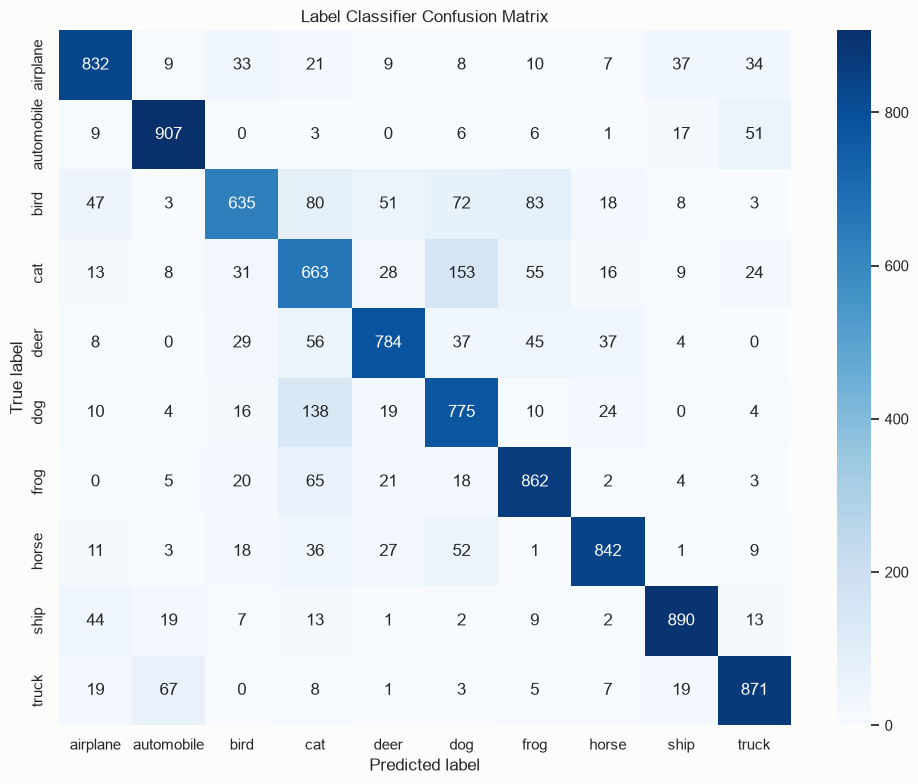

0.8062230098102973


In [30]:
label_cls.load_state_dict(best_state_dict)
label_cls.eval()
y_true, y_pred = [], []
test_loader = DataLoader(
    test_data, batch_size=64, shuffle=False,
    num_workers=cpu_cores, pin_memory=True,
    persistent_workers=True, prefetch_factor=2
)

with torch.no_grad():
    for batch in test_loader:
        images = batch['img'].to(device)
        labels = batch['label'].argmax(dim=1)
        predictions = label_cls(images).argmax(dim=1).cpu()
        y_true.append(labels.cpu())
        y_pred.append(predictions)

y_true = torch.cat(y_true)
y_pred = torch.cat(y_pred)
f1_scores = []

for class_id in range(10):
    tp = ((y_pred == class_id) & (y_true == class_id)).sum().item()
    fp = ((y_pred == class_id) & (y_true != class_id)).sum().item()
    fn = ((y_pred != class_id) & (y_true == class_id)).sum().item()
    denominator = 2 * tp + fp + fn
    f1_scores.append(2 * tp / denominator if denominator else 0.0)

macro_f1 = sum(f1_scores) / len(f1_scores)
print(f'Test macro F1: {macro_f1:.4f}')

matrix = torch.zeros(10, 10, dtype=torch.int64)
for actual, predicted in zip(y_true, y_pred):
    matrix[actual, predicted] += 1

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10, 8))
sns.heatmap(matrix.numpy(), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Label Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

print(macro_f1)


In [41]:
from sklearn.metrics import normalized_mutual_info_score

G.eval()
requested_labels, predicted_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        labels = batch['label'].to(device).float()
        noise = torch.randn(labels.size(0), noise_dim, device=device)
        generated_images = G(noise, labels)

        requested_labels.append(labels.argmax(dim=1).cpu())
        predicted_labels.append(label_cls(generated_images).argmax(dim=1).cpu())

requested_labels = torch.cat(requested_labels).numpy()
predicted_labels = torch.cat(predicted_labels).numpy()
nmi = normalized_mutual_info_score(requested_labels, predicted_labels)

print(f'Normalized mutual information: {nmi:.4f}')

Normalized mutual information: 0.1499


### Conclusion: 

The NMI between the 10,000 requested labels and the auxiliary classifier's predictions is `0.1499`. This low value indicates weak statistical dependence between the requested class and the class inferred from the generated image, providing evidence that the generator does not separate the 10 requested classes reliably. The result is consistent with the visual similarity between several class columns in the fixed-noise progression grid. 

However, the NMI should not be treated as an exact class-accuracy measurement as the auxiliary classifier is imperfect. Additionally, NMI does not require predicted label identities to match requested identities, and the generated images differ from the real-image domain on which the classifier was evaluated. The score is also based on newly sampled noise, so a rerun may vary slightly.

### 8.4 Nearest-Neighbor Check

For each class, the code generates 10 samples, flattens them and all real training images of that class, and uses Euclidean pixel distance to identify the nearest real training example. The resulting 100 generated/nearest-real pairs provide a limited memorization check: a distance of zero would identify an exact pixel duplicate, while visibly different pairs and non-zero distances argue against direct copying within this sample. However, raw pixel distance is sensitive to small translations, colour changes, and other low-level differences, so it cannot rule out broader forms of memorization.

Mean nearest-neighbour distance per class
airplane: 18.2991
car: 24.6419
bird: 18.4089
cat: 24.6105
deer: 19.3017
dog: 21.4736
frog: 20.7001
horse: 21.9966
ship: 20.9801
truck: 25.0199


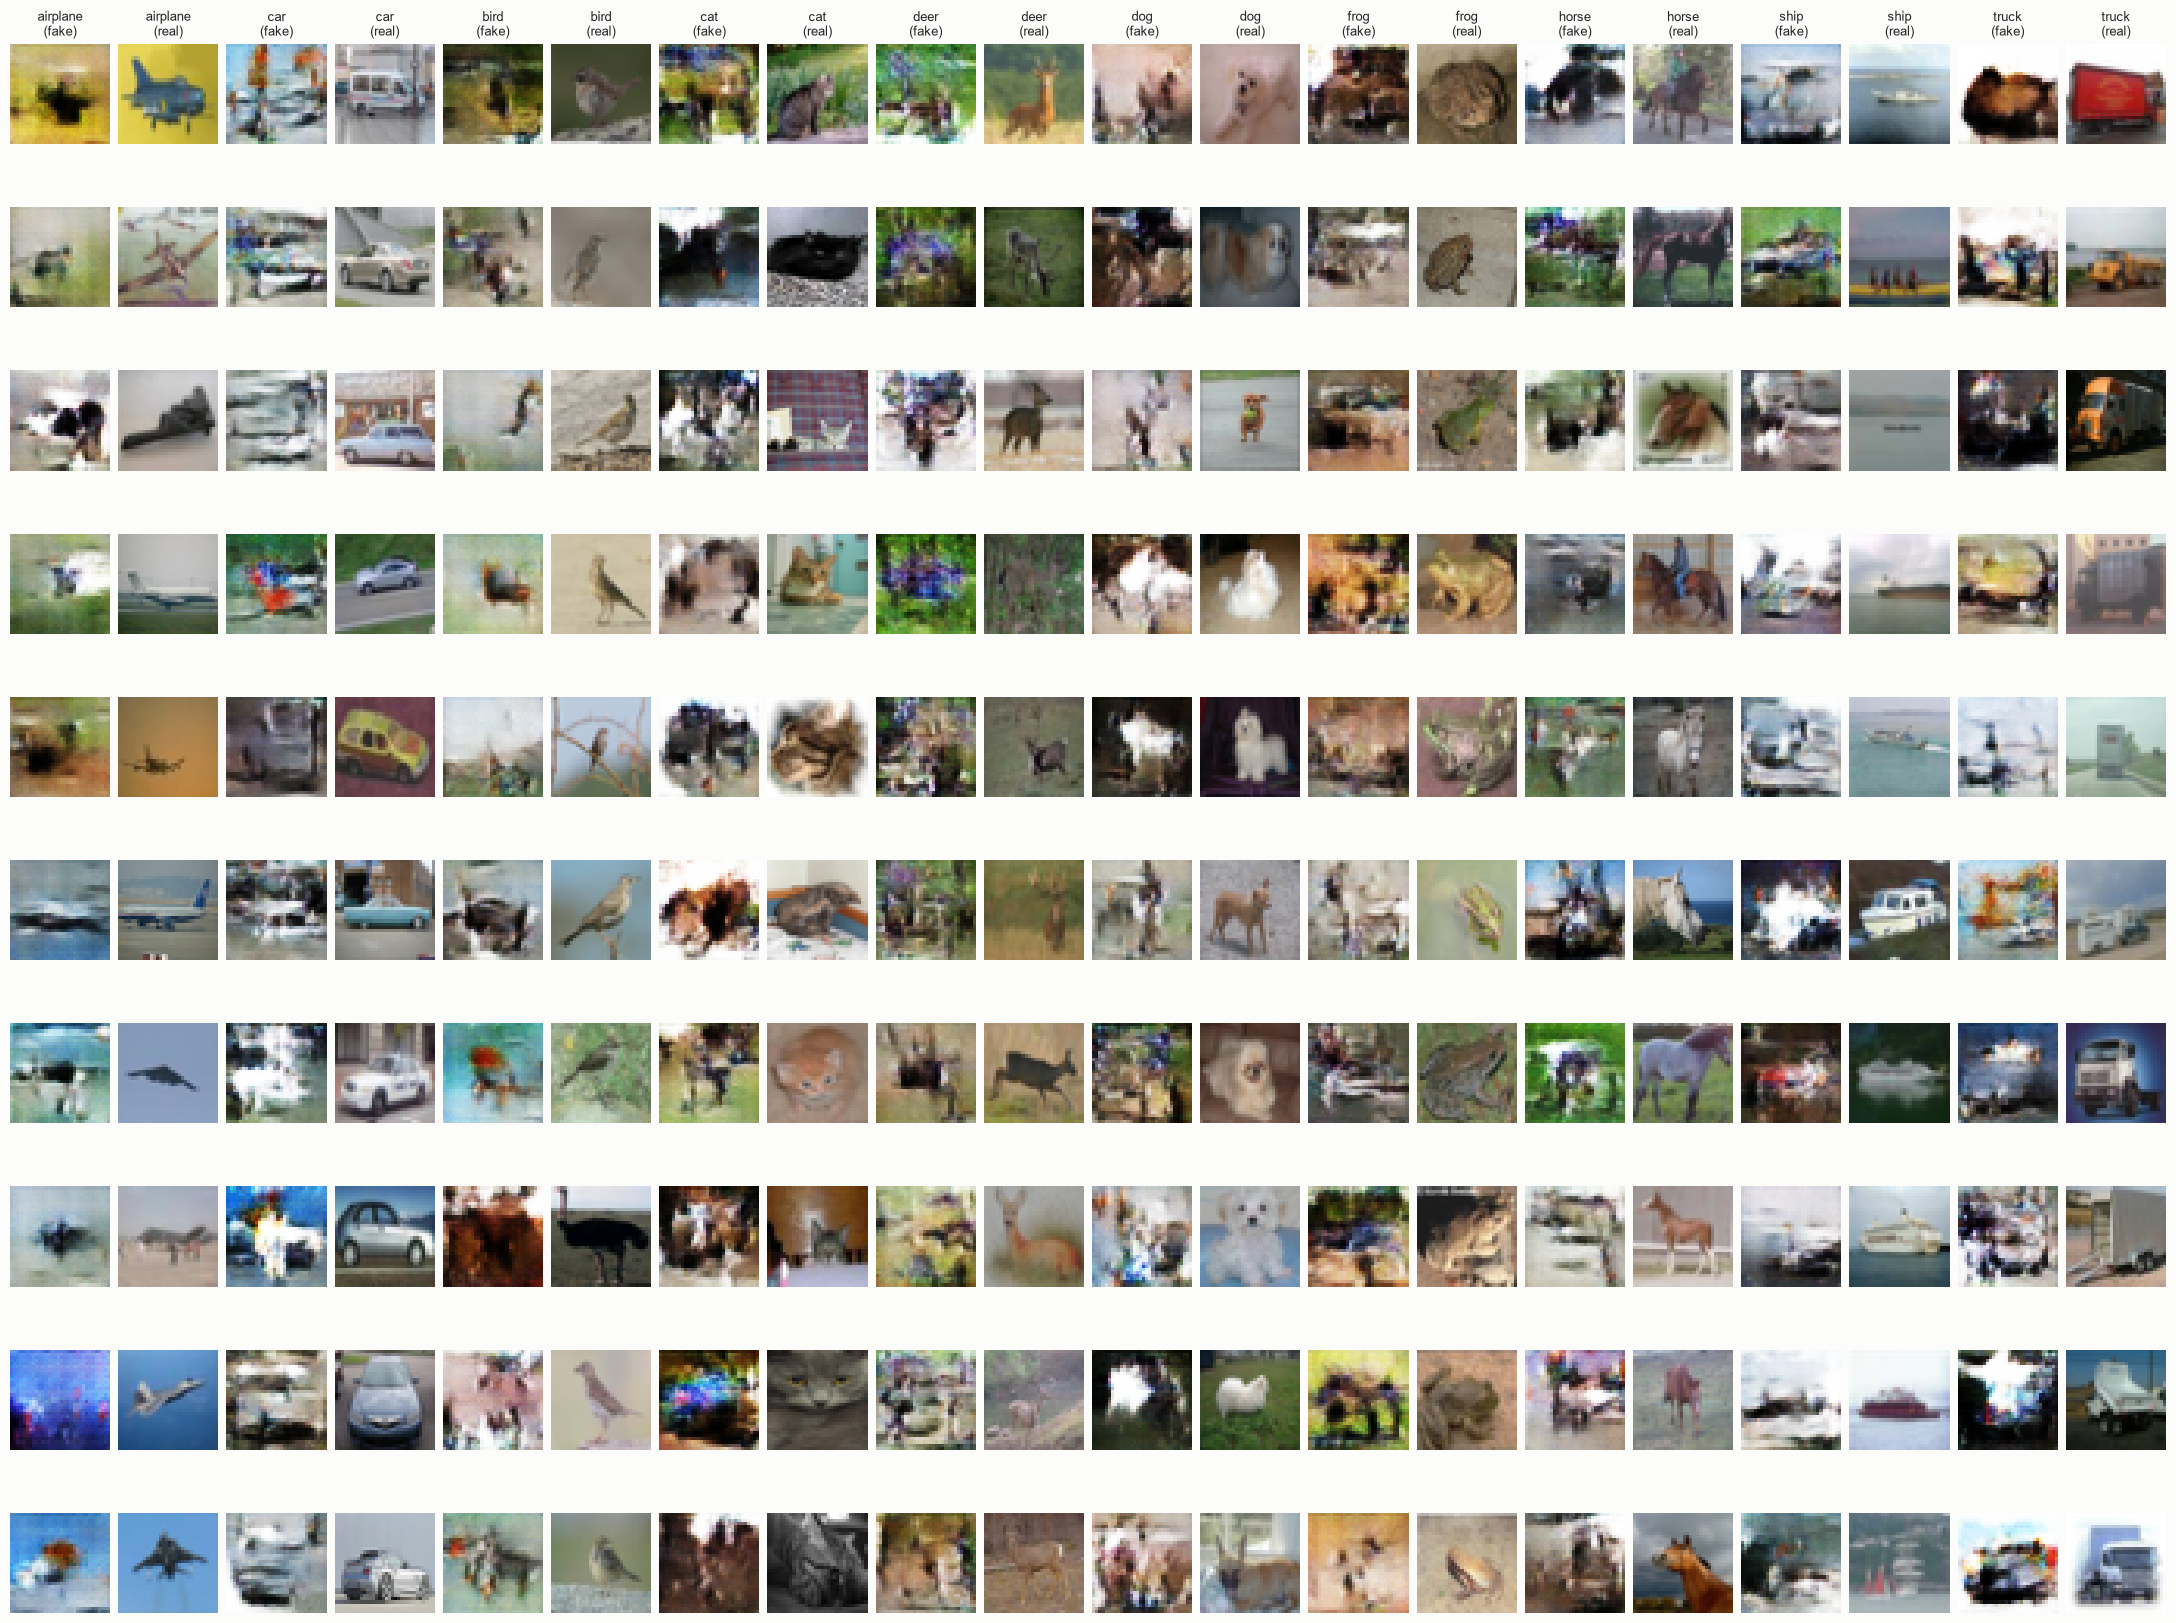

In [31]:
# For a few generated images, find and display the nearest real training image by pixel distance, side by side.
def nearest_neighbour_memorisation_check(G, train_loader, classes, noise_dim, device, n_generated_per_class=5):
    G.eval()

    train_images_per_class = {class_idx: [] for class_idx in range(len(classes))}

    # Collect real training images by class
    for sample in train_loader:
        images = sample["img"]
        labels = sample["label"]

        # Supports labels shaped (B, 10, 1) or (B, 10)
        class_indices = labels.squeeze(-1).argmax(dim=1)

        for img, class_idx in zip(images, class_indices):
            train_images_per_class[class_idx.item()].append(img.cpu())

    for class_idx in train_images_per_class:
        train_images_per_class[class_idx] = torch.stack(train_images_per_class[class_idx])

    generated_images_per_class = {}
    nearest_images_per_class = {}
    nearest_distances_per_class = {}
    mean_distances_per_class = {}

    with torch.no_grad():
        for class_idx, class_name in enumerate(classes):
            noise = torch.randn(n_generated_per_class, noise_dim, device=device)
            one_hot_labels = torch.zeros(n_generated_per_class, len(classes), device=device)
            one_hot_labels[:, class_idx] = 1

            generated_images = G(noise, one_hot_labels).cpu()
            training_images = train_images_per_class[class_idx]

            generated_flat = generated_images.flatten(start_dim=1)
            training_flat = training_images.flatten(start_dim=1)

            distances = torch.cdist(generated_flat, training_flat, p=2)
            nearest_distances, nearest_indices = distances.min(dim=1)
            nearest_images = training_images[nearest_indices]

            generated_images_per_class[class_name] = generated_images
            nearest_images_per_class[class_name] = nearest_images
            nearest_distances_per_class[class_name] = nearest_distances
            mean_distances_per_class[class_name] = nearest_distances.mean().item()

    # Print mean nearest-neighbour distance for each class
    print("Mean nearest-neighbour distance per class")

    for class_name in classes:
        print(f"{class_name}: {mean_distances_per_class[class_name]:.4f}")

    # Each class occupies two columns:
    # class (fake) | class (real)
    # Each row represents one generated sample
    fig, ax = plt.subplots(n_generated_per_class, len(classes) * 2, figsize=(2.2 * len(classes), 1.8 * n_generated_per_class), squeeze=False)

    for class_idx, class_name in enumerate(classes):
        fake_col = class_idx * 2
        real_col = fake_col + 1

        ax[0][fake_col].set_title(f"{class_name}\n(fake)", fontsize=9, pad=6)
        ax[0][real_col].set_title(f"{class_name}\n(real)", fontsize=9, pad=6)

        generated_images = generated_images_per_class[class_name]
        nearest_images = nearest_images_per_class[class_name]

        for sample_idx in range(n_generated_per_class):
            generated_img = generated_images[sample_idx]
            nearest_img = nearest_images[sample_idx]

            ax[sample_idx][fake_col].imshow(F_t.to_pil_image((127.5 * (generated_img + 1)).to(torch.uint8)))
            ax[sample_idx][real_col].imshow(F_t.to_pil_image((127.5 * (nearest_img + 1)).to(torch.uint8)))

            ax[sample_idx][fake_col].axis("off")
            ax[sample_idx][real_col].axis("off")

    plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.02, wspace=0.08, hspace=0.08)
    plt.show()

    return {
        "generated_images": generated_images_per_class,
        "nearest_training_images": nearest_images_per_class,
        "nearest_distances": nearest_distances_per_class,
        "mean_distances": mean_distances_per_class
    }
nearest_neighbour_results = nearest_neighbour_memorisation_check(
    G=G,
    train_loader=train_loader,
    classes=classes,
    noise_dim=noise_dim,
    device=device,
    n_generated_per_class=10
)

### Conclusion: 

All 100 generated samples had non-zero nearest-neighbour distances within the corresponding requested-class subset of the training data. The class means range from `18.2991` for airplane to `25.0199` for truck. Truck, car (`24.6419`), and cat (`24.6105`) have the largest mean distances, while airplane, bird (`18.4089`), and deer (`19.3017`) have the smallest. The displayed generated/real pairs are visibly different, so this check found no exact pixel copies within those searched class subsets. It does not establish that the model never memorizes training content, because only 100 generated images were tested, training images assigned to other labels were not searched, and Euclidean pixel distance is not invariant to minor image transformations.

## 9. Generate 1000 Class-Conditioned Images

### 9.1 Sample and Generate

The generator is placed in evaluation mode and receives 100 newly sampled 128-dimensional Gaussian noise vectors for each one-hot class label. Running under `torch.no_grad()` produces 100 images per class without involving the discriminator or any real image, and the resulting tensors are concatenated into a balanced batch of 1,000 generated images with their class indices.

In [32]:
# Sample random noise vectors, generate with each of the 10 class labels to produce 100 images per class (1000 total).
images_per_class = 100
generated_images = []
generated_labels = []

G.eval()
with torch.no_grad():
    for class_idx in range(len(classes)):
        noise = torch.randn(images_per_class, noise_dim, device=device)
        one_hot_labels = torch.zeros(images_per_class, len(classes), device=device)
        one_hot_labels[:, class_idx] = 1

        class_images = G(noise, one_hot_labels)
        generated_images.append(class_images.cpu())
        generated_labels.append(torch.full((images_per_class,), class_idx))

generated_images = torch.cat(generated_images)
generated_labels = torch.cat(generated_labels)

print("generated_images:", generated_images.shape)
print("generated_labels:", generated_labels.shape)

generated_images: torch.Size([1000, 3, 32, 32])
generated_labels: torch.Size([1000])


### 9.2 Save to Disk

Before saving, each generated tensor is converted from `[-1, 1]` back to `[0, 1]` and clamped to a valid image range. The files are written as `000.png` through `099.png` inside `gan_generated_images/<class_name>/`, giving 10 class folders containing 100 submission images each.

In [33]:
# Save the generated images to disk as required for submission.
import os
from torchvision.utils import save_image

output_dir = "gan_generated_images"

for class_idx, class_name in enumerate(classes):
    class_dir = os.path.join(output_dir, class_name)
    os.makedirs(class_dir, exist_ok=True)

    class_images = generated_images[generated_labels == class_idx]
    for i, image in enumerate(class_images):
        image_01 = ((image + 1) / 2).clamp(0, 1)
        save_image(image_01, os.path.join(class_dir, f"{i:03d}.png"))

print(f"Saved {len(generated_images)} images to {output_dir}/<class_name>/")

Saved 1000 images to gan_generated_images/<class_name>/


### 9.3 Preview Grid

The preview selects the first six generated images from every class and displays them as a 10-row by 6-column grid, with class names labelling the rows. Converting the model output back to uint8 makes the samples directly viewable and allows a quick check of colour, class cues, diversity, and obvious corruption without rendering all 1,000 files.

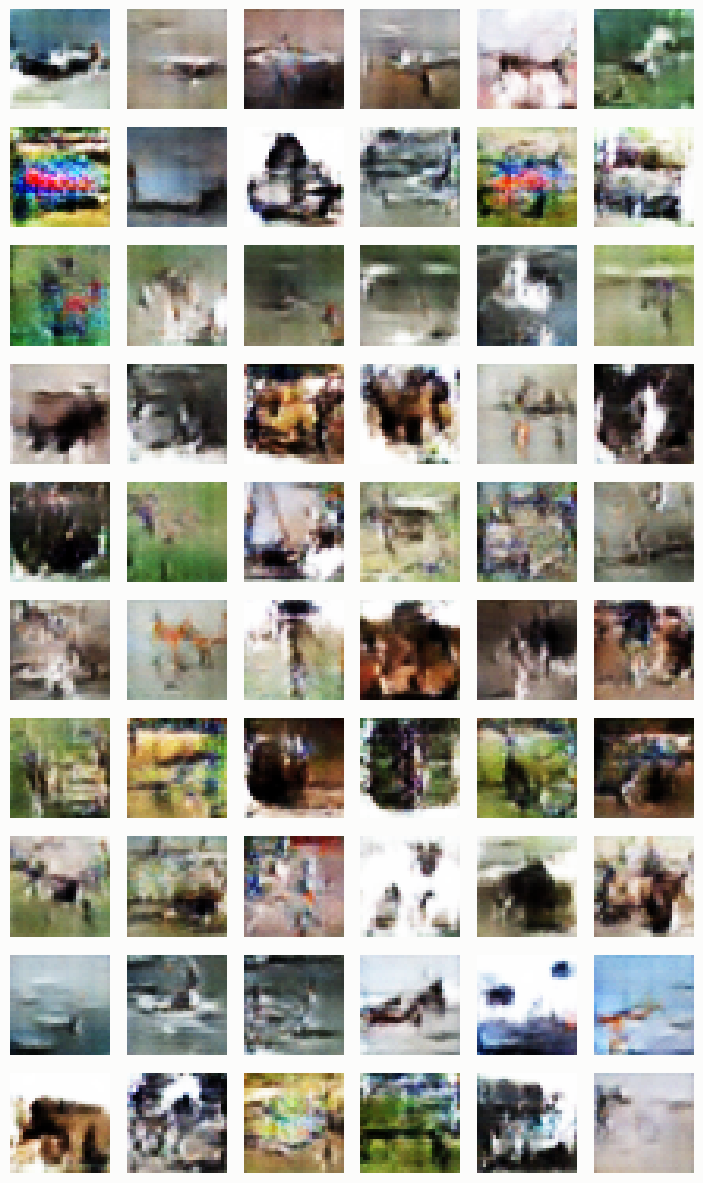

In [34]:
# Display a grid of sample generated images, a few per class, for visual inspection.
n_preview = 6
fig, ax = plt.subplots(len(classes), n_preview, figsize=(n_preview * 1.2, len(classes) * 1.2))

for class_idx, class_name in enumerate(classes):
    class_images = generated_images[generated_labels == class_idx][:n_preview]

    for col in range(n_preview):
        image = (127.5 * (class_images[col] + 1)).to(torch.uint8)
        ax[class_idx][col].imshow(F_t.to_pil_image(image))
        ax[class_idx][col].axis("off")

        if col == 0:
            ax[class_idx][col].set_ylabel(
                class_name,
                rotation=0,
                ha="right",
                va="center"
            )

plt.tight_layout()
plt.show()

### Conclusion: 

The preview contains recurring class-associated colour and background cues: ship images often include blue horizontal regions resembling water or sky, while several vehicle and animal samples contain coarse object-like silhouettes. Nevertheless, boundaries and fine details remain blurred, and many of the animal classes are visually difficult to distinguish from one another. The six displayed examples per class therefore suggest that the generator learned partial CIFAR10 appearance cues but did not apply them with reliable class specificity or perceptual clarity. This grid is a qualitative subset and should be interpreted together with the 100-image eye test rather than as a complete evaluation.

## 10. Evaluate Generated Image Quality

### 10.1 Eye-Test Scoring

The interactive loop displays 10 images from each class individually and records `0` for nonsense, `0.5` for a marginal image with partial class cues, or `1` for a clearly recognizable class example. Input validation restricts entries to those three values, producing 100 scores in `eye_test_scores`. Applying the same rubric as the CVAE supports a direct descriptive comparison, while FID provides a separate feature-based measurement. The eye test remains subjective and is based on only 10 generated images per class, so its totals should be interpreted as a transparent assessment of this sample rather than an objective population estimate.

In [35]:
# Manually score 10 generated images per class as nonsense (0), marginal (0.5), or clear (1).
from IPython.display import clear_output, display

n_score = 10
valid_scores = {"0": 0.0, "0.5": 0.5, "1": 1.0}
eye_test_scores = {class_name: [] for class_name in classes}

for class_idx, class_name in enumerate(classes):
    class_images = generated_images[generated_labels == class_idx][:n_score]

    for image_idx, image in enumerate(class_images):
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(3, 3))
        image_01 = ((image + 1) / 2).clamp(0, 1)
        ax.imshow(image_01.permute(1, 2, 0).cpu().numpy())
        ax.set_title(f"Class: {class_name} | Image: {image_idx + 1}/{n_score}")
        ax.axis("off")
        plt.tight_layout()
        display(fig)

        while True:
            score_input = input(
                "Score (0 = nonsense, 0.5 = marginal, 1 = clear): "
            ).strip()

            if score_input in valid_scores:
                eye_test_scores[class_name].append(valid_scores[score_input])
                break

            print("Invalid score. Enter only 0, 0.5, or 1.")

        plt.close(fig)

clear_output(wait=True)
print(f"Scoring complete: {sum(len(scores) for scores in eye_test_scores.values())} images scored")
eye_test_scores

Scoring complete: 100 images scored


{'airplane': [0.5, 0.5, 0.5, 0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0],
 'car': [0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.5, 0.5, 0.0],
 'bird': [0.5, 0.5, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.5, 0.5],
 'cat': [0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 1.0],
 'deer': [0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5],
 'dog': [1.0, 0.5, 0.0, 0.0, 0.5, 1.0, 0.0, 0.0, 0.5, 0.5],
 'frog': [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.5, 0.5],
 'horse': [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.5],
 'ship': [0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 1.0, 0.0],
 'truck': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0, 0.0]}

### 10.2 Per-Class Score Summary

The numeric scores are converted into clear, marginal, and nonsense counts for every class and plotted as stacked bars. Car and dog have the joint-highest number of clear samples with two each; cat and ship have one each, and the remaining classes have none. Dog has the fewest nonsense samples with four, whereas truck has the most with eight. The table makes these class-level differences explicit while retaining the original 10-image sample size for each class.

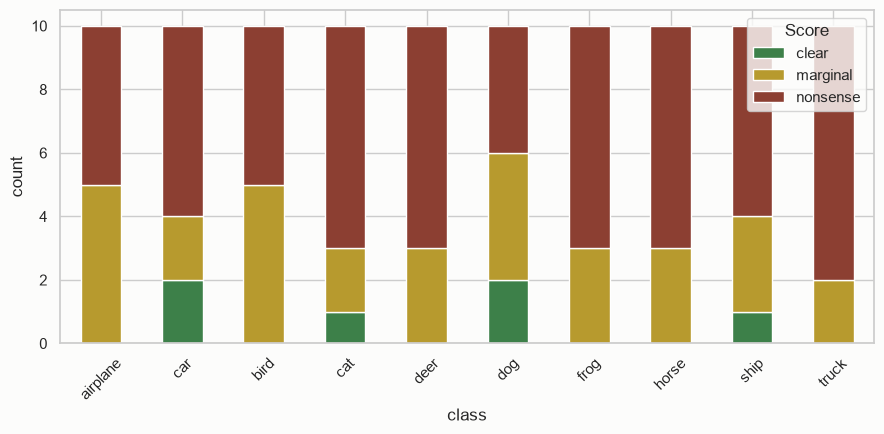

,clear,marginal,nonsense
airplane,0,5,5
car,2,2,6
bird,0,5,5
cat,1,2,7
deer,0,3,7
dog,2,4,4
frog,0,3,7
horse,0,3,7
ship,1,3,6
truck,0,2,8


In [36]:
# Tally clear/marginal/nonsense counts per class, bar chart the result.
import pandas as pd

categories = {1.0: "clear", 0.5: "marginal", 0.0: "nonsense"}
tally = pd.DataFrame(
    {
        label: [eye_test_scores[class_name].count(score) for class_name in classes]
        for score, label in categories.items()
    },
    index=classes
)

fig, ax = plt.subplots(figsize=(9, 4.5))
tally.plot(
    kind="bar",
    stacked=True,
    color=[PALETTE[2], PALETTE[7], PALETTE[6]],
    ax=ax
)
ax.set_ylabel("count")
ax.set_xlabel("class")
plt.xticks(rotation=45)
ax.legend(title="Score")
plt.tight_layout()
plt.show()

tally

### Conclusion: 

Across the 100 manually reviewed images, `6` were rated clear, `32` marginal, and `62` nonsense. With scores of `1`, `0.5`, and `0` respectively, the overall mean is `0.220`. Dog is the strongest class in this sample with a mean of `0.400` (2 clear, 4 marginal, and 4 nonsense), followed by car at `0.300`. Truck is weakest at `0.100` with 8 nonsense images; deer, frog, and horse each score `0.150`. The evaluation therefore shows occasional recognizable outputs but poor consistency overall. Because only 10 images per class were scored by a human evaluator, these class rankings are descriptive of this sample rather than precise population estimates.

### 10.3 Discussion: Class Difficulty

The GAN's strongest sampled class is dog with a mean eye-test score of `0.400`, followed by car at `0.300`; truck is weakest at `0.100`. The saved CVAE eye-test results show a different pattern: cat is strongest at `0.650`, automobile scores `0.050`, and truck also scores `0.100`. Thus, car appears substantially stronger in this GAN sample than automobile does in the CVAE sample, while truck remains difficult for both models. Cat falls from the CVAE's strongest class to a GAN mean of `0.200`, although the GAN sample does contain one clear cat. These comparisons use only 10 manually scored images per class for each model, so they indicate observed tendencies rather than statistically stable class rankings.

### 10.4 Discussion: Color vs. Black-and-White (Prediction)

The prediction is that grayscale generation will be harder overall despite reducing the output from three channels to one, because colour and background tone are useful class cues in low-resolution CIFAR10 images and removing them forces the GAN to rely more heavily on shape and texture. This baseline trains only on RGB images, so the statement remains a hypothesis; the controlled colour-versus-grayscale experiment in `gan_improvement.ipynb` Section 7 should be used for the empirical conclusion.

## 11. Baseline Conclusion

After 50 epochs, the baseline conditional DCGAN produces images with measurable pixel-level variation and occasional recognizable class cues, but both image quality and class control remain limited. Mean per-pixel standard deviations are close to those of real validation images, so that diagnostic does not indicate severe within-class pixel collapse. However, the requested-versus-predicted label NMI is only `0.1499`, indicating weak between-class separation, and the fixed-noise grid also shows substantial similarity across several labels. The nearest-neighbour check found no exact pixel copies among 100 sampled generated images within their requested-class training subsets, although that limited test cannot rule out memorization. In the manual evaluation, 6 images were clear, 32 marginal, and 62 nonsense, giving a mean score of `0.220`; the FID score is `121.3981`. Together, these results establish a reproducible but weak baseline for the controlled comparisons in `gan_improvement.ipynb`. The final model weights are stored in `baseline_g.pt` and `baseline_d.pt`, and the recorded configuration, final-batch losses, eye-test scores, and FID are saved in `gan_baseline_results.json`.

In [37]:
# Save baseline config, final losses, eye-test scores, and FID score to a small JSON file for gan_improvement.ipynb to load.
import json as _json

def save_baseline_results(fid_score):
    baseline_results = {
        "noise_dim": noise_dim,
        "batch_size": bs,
        "num_epochs": len(g_loss_track["train"]),
        "generator_lr": g_lr,
        "discriminator_lr": d_lr,
        "final_train_g_loss": g_loss_track["train"][-1],
        "final_val_g_loss": g_loss_track["val"][-1],
        "final_train_real_d_loss": real_d_loss_track["train"][-1],
        "final_val_real_d_loss": real_d_loss_track["val"][-1],
        "final_train_fake_d_loss": fake_d_loss_track["train"][-1],
        "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
        "eye_test_scores": eye_test_scores,
        "fid_score": fid_score,
    }

    with open("gan_baseline_results.json", "w") as f:
        _json.dump(baseline_results, f, indent=2)

    print("Saved baseline_results to gan_baseline_results.json")
    return baseline_results

In [38]:
# Extract InceptionV3 features for a sample of real validation images and for the 1000 generated images.
from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = len(generated_images)
real_samples_seen = 0

with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - real_samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        real_images = ((real_images + 1) / 2).clamp(0, 1)
        fid.update(real_images, real=True)
        real_samples_seen += len(real_images)

    for start in range(0, fid_n_samples, bs):
        fake_images = generated_images[start:start + bs].to(device)
        fake_images = ((fake_images + 1) / 2).clamp(0, 1)
        fid.update(fake_images, real=False)

print(f"Collected Inception features for {real_samples_seen} real and {fid_n_samples} generated images")

Collected Inception features for 1000 real and 1000 generated images


In [39]:
# Fit a Gaussian (mean, covariance) to each feature set, compute Frechet distance between them, print the FID score.
# TorchMetrics performs the Gaussian fitting and Frechet-distance calculation internally.
fid_score = fid.compute().item()
print(f"FID score: {fid_score:.4f}")

baseline_results = save_baseline_results(fid_score)

FID score: 121.3981
Saved baseline_results to gan_baseline_results.json


### Conclusion: 

Using 1,000 real validation images and 1,000 generated images, TorchMetrics reports an FID score of `121.3981`. Lower FID indicates closer agreement between the two Inception-feature distributions, so this result reflects a substantial remaining discrepancy between generated and real CIFAR10 samples under the present evaluation pipeline. It is consistent with the qualitative blur and the manual result in which 62 of 100 images were rated nonsense. Because FID estimates depend on sample count, feature implementation, and sampled images, `121.3981` should be treated as the comparison baseline for later experiments evaluated with the same 1,000-versus-1,000 procedure, rather than as a universal threshold.